# Italian Financial Challenge: Bankruptcy Prediction

**Student Name:** Deniz Mehmet Taylan, Gustavo Depieri Fioravanti, Yarkin Yavuz, Koray Aydin  
**Challenge:** Challenge 1 (Predicting which Italian companies will go bankrupt)  
**Date:** 27/04/2026


## 1. Problem Overview

We're trying to predict which Italian companies will go bankrupt within the next 12 months. 
This is a binary classification problem, but with one big complication: bankruptcies are rare, 
making up only `84 / 11,828` training observations, or about `0.71%`. A model that just predicts 'healthy' for everything 
would look accurate but would miss every bankruptcy.

The target variable is `bankruptcy_next_year` (0 = survived, 1 = bankrupt).

**How we approach this:**
- F1-score is our main model selection metric, and it rewards the balance between catching bankruptcies and avoiding false alarms
- PR-AUC is our secondary focus, since it's more informative than ROC-AUC when positives are rare
- After picking the best model, we do a separate business threshold analysis: in credit risk, missing a bankruptcy 
is far more costly than flagging a healthy company, so we tune the decision threshold for that asymmetry separately
- All data splits are strictly time-based, with no random shuffling that would let future information leak into training


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import PerformanceWarning

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import DMatrix, XGBClassifier
import shap

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
warnings.simplefilter("ignore", PerformanceWarning)
warnings.simplefilter("ignore", FutureWarning)

RANDOM_STATE = 42


## 2. Data Loading and EDA

The training set covers fiscal years 2018–2021 (11,828 observations), and the test set covers 2022–2023 
(5,811 observations). Each company appears across multiple years, so we're working with a panel dataset.

This section checks raw data quality and the main exploratory patterns.
One important data quirk appears immediately: the `province` column uses Italian province codes, and Napoli's code is `NA` (
which pandas silently reads as a missing value). We fix this before any analysis.

In [2]:
train_df = pd.read_csv("../data/processed/train_data.csv")
test_df = pd.read_csv("../data/processed/test_features.csv")

excluded_cols = ["financial_health_class", "revenue_change"]
train_df = train_df.drop(columns=[col for col in excluded_cols if col in train_df.columns])
test_df = test_df.drop(columns=[col for col in excluded_cols if col in test_df.columns])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain years:", sorted(train_df["fiscal_year"].unique()))
print("Test years:", sorted(test_df["fiscal_year"].unique()))

Train shape: (11828, 28)
Test shape: (5811, 27)

Train years: [2018, 2019, 2020, 2021]
Test years: [2022, 2023]


Missing values:


,missing_count,missing_pct
province,919,7.77
roe,45,0.38
leverage,45,0.38


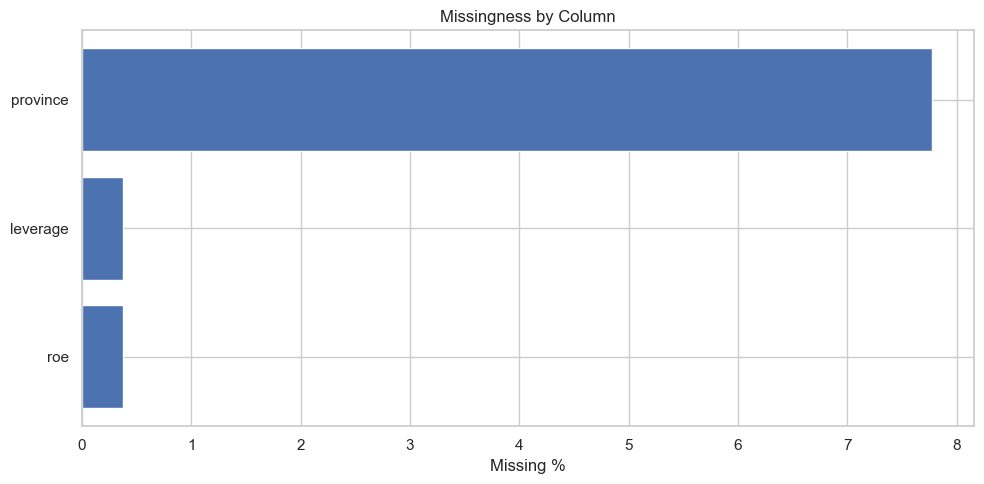

In [3]:
missing_summary = pd.DataFrame({
    "missing_count": train_df.isna().sum(),
    "missing_pct": train_df.isna().mean().mul(100).round(2),
}).sort_values(["missing_count", "missing_pct"], ascending=False)

print("Missing values:")
display(missing_summary[missing_summary["missing_count"] > 0])

missing_plot_df = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=True)
if not missing_plot_df.empty:
    plt.figure(figsize=(10, 5))
    plt.barh(missing_plot_df.index, missing_plot_df["missing_pct"], color="#4c72b0")
    plt.xlabel("Missing %")
    plt.title("Missingness by Column")
    plt.tight_layout()
    plt.savefig("../images/missing_values.png", bbox_inches="tight", dpi=150)
    plt.show()

### 2.1 Missingness and Data Notes

The first missingness check shows only a small amount of raw missing data. There are two points worth stating clearly.

- `province`: the code `NA` corresponds to Napoli, so these rows are corrected before any regional analysis.
- `roe` and `leverage`: both are missing in 45 rows each (`0.38%` of the training data). These are not random gaps. In all of these cases, shareholders' equity is negative, so equity-based ratios become economically unstable and are treated as undefined rather than as ordinary numeric values.


In [4]:
print("Province values read as missing:", int(train_df["province"].isna().sum()))
print("Interpretation: these rows are treated as Napoli because code 'NA' is parsed as missing by pandas.")

yearly_target_summary = (
    train_df.groupby("fiscal_year")["bankruptcy_next_year"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "bankruptcies", "mean": "bankruptcy_rate"})
)
display(yearly_target_summary.style.format({"bankruptcy_rate": "{:.2%}"}))

print("\nOverall target distribution:")
display(
    pd.DataFrame({
        "count": train_df["bankruptcy_next_year"].value_counts().sort_index(),
        "share": train_df["bankruptcy_next_year"].value_counts(normalize=True).sort_index().round(4),
    })
)

Province values read as missing: 919
Interpretation: these rows are treated as Napoli because code 'NA' is parsed as missing by pandas.


,count,bankruptcies,bankruptcy_rate
fiscal_year,,,
2018,2961,23,0.78%
2019,2979,24,0.81%
2020,2956,16,0.54%
2021,2932,21,0.72%



Overall target distribution:


,count,share
bankruptcy_next_year,,
0,11744,0.9929
1,84,0.0071


### 2.2 Bankruptcy Distribution by Year and Sector

Before diving into financial ratios, it helps to understand whether bankruptcy rates are consistent 
across years or concentrated in specific periods. A spike in 2020–2021 could reflect COVID-related 
distress rather than structural firm weakness. The sector breakdown tells us which industries drive the count.

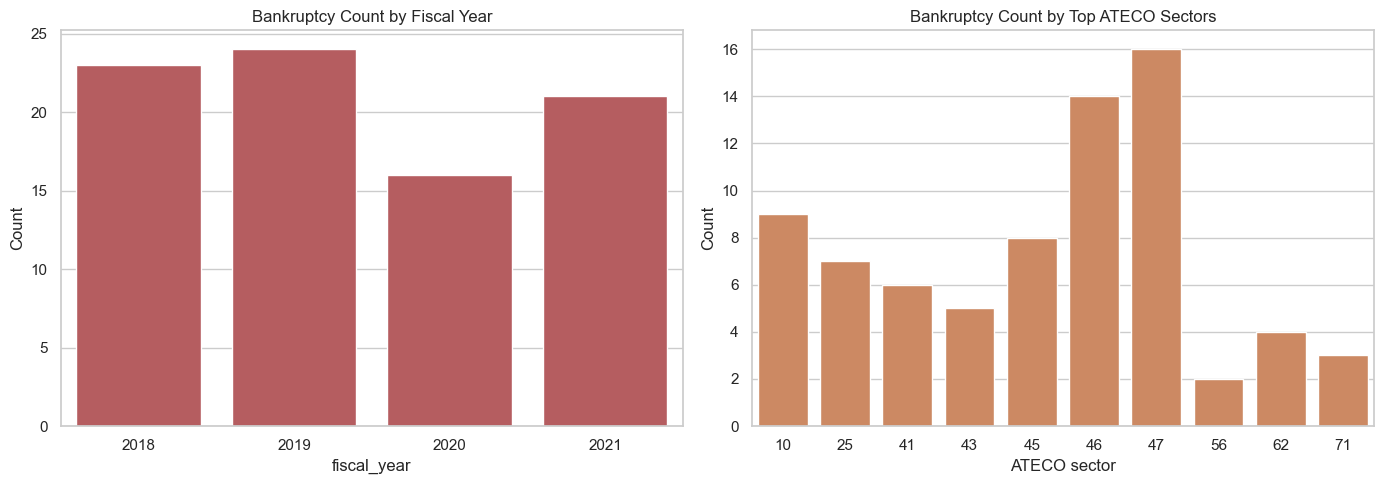

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_plot = yearly_target_summary.reset_index()
sns.barplot(data=yearly_plot, x="fiscal_year", y="bankruptcies", ax=axes[0], color="#c44e52")
axes[0].set_title("Bankruptcy Count by Fiscal Year")
axes[0].set_ylabel("Count")

top_sectors = train_df["ateco_sector"].value_counts().head(10).index
sector_count = (
    train_df[train_df["ateco_sector"].isin(top_sectors)]
    .groupby("ateco_sector")["bankruptcy_next_year"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=sector_count, x="ateco_sector", y="bankruptcy_next_year", ax=axes[1], color="#dd8452")
axes[1].set_title("Bankruptcy Count by Top ATECO Sectors")
axes[1].set_xlabel("ATECO sector")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../images/yearly_sector_bankruptcies.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.3 Panel Completeness

Not every company appears in all four labeled years. In financial data, that's rarely random, and a company 
that drops off the panel might have shut down, merged, or gone through restructuring. Companies with 
incomplete panels tend to have different risk profiles than fully observed firms.

Bankruptcy rate by panel completeness:


,bankruptcy_rate,bankruptcies,rows
Complete (4 years),0.0032,37,11580
Incomplete (<4 years),0.1895,47,248


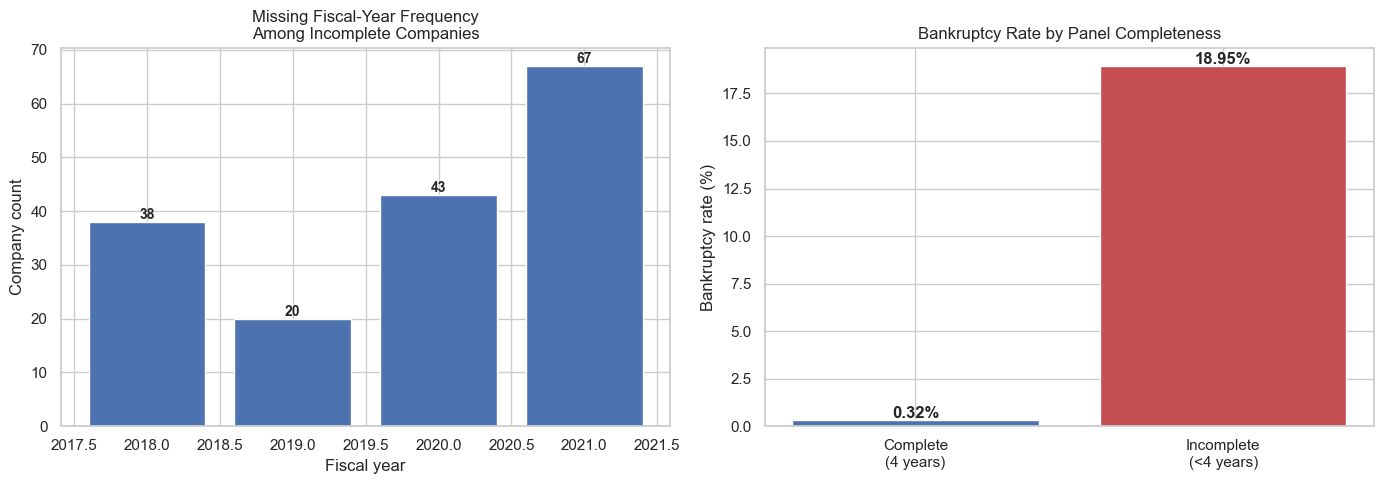

Company count by years observed:


,companies
years_observed,
1,20
2,24
3,60
4,2895


In [6]:
full_years = sorted(train_df["fiscal_year"].unique())
company_years = train_df.groupby("company_id")["fiscal_year"].apply(lambda s: set(s.tolist()))
company_year_counts = train_df.groupby("company_id")["fiscal_year"].nunique()
incomplete_ids = company_year_counts[company_year_counts < len(full_years)].index

panel_df = train_df.copy()
panel_df["incomplete_panel"] = panel_df["company_id"].isin(incomplete_ids).astype(int)
panel_df["years_observed"] = panel_df.groupby("company_id")["fiscal_year"].transform("nunique")

panel_summary = (
    panel_df.groupby("incomplete_panel")["bankruptcy_next_year"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "bankruptcy_rate", "sum": "bankruptcies", "count": "rows"})
)
panel_summary.index = ["Complete (4 years)", "Incomplete (<4 years)"]
print("Bankruptcy rate by panel completeness:")
display(panel_summary.round(4))

missing_per_year = {}
incomplete_year_sets = company_years.loc[incomplete_ids]
for yr in full_years:
    missing_per_year[yr] = int(incomplete_year_sets.apply(lambda s: yr not in s).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(list(missing_per_year.keys()), list(missing_per_year.values()), color="#4c72b0")
for yr, cnt in missing_per_year.items():
    axes[0].text(yr, cnt + 0.5, str(cnt), ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Missing Fiscal-Year Frequency\nAmong Incomplete Companies")
axes[0].set_xlabel("Fiscal year")
axes[0].set_ylabel("Company count")

panel_rate_pct = panel_summary["bankruptcy_rate"].mul(100).tolist()
axes[1].bar(["Complete\n(4 years)", "Incomplete\n(<4 years)"], panel_rate_pct, color=["#4c72b0", "#c44e52"])
axes[1].set_title("Bankruptcy Rate by Panel Completeness")
axes[1].set_ylabel("Bankruptcy rate (%)")
for i, value in enumerate(panel_rate_pct):
    axes[1].text(i, value + 0.1, f"{value:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

years_observed_summary = (
    panel_df.drop_duplicates("company_id")
    .groupby("years_observed")["incomplete_panel"]
    .size()
    .to_frame("companies")
)
print("Company count by years observed:")
display(years_observed_summary)

In [7]:
eda_df = train_df.copy().sort_values(["company_id", "fiscal_year"]).reset_index(drop=True)

province_series = eda_df["province"].astype("string").str.strip()
province_na_code_mask = province_series.isna() | province_series.str.upper().eq("NA").fillna(False)
eda_df["province_missing"] = province_na_code_mask.astype(int)
eda_df.loc[province_na_code_mask, "province"] = "Napoli"

def eda_safe_divide(num, den):
    return num / den.replace(0, np.nan)


def assign_eda_year_specific_size_tier(df, value_col="production_value", year_col="fiscal_year", n_tiers=10):
    tier = pd.Series(np.nan, index=df.index, dtype="float64")
    for _, year_idx in df.groupby(year_col).groups.items():
        year_values = df.loc[year_idx, value_col]
        valid_idx = year_values[year_values.notna()].index
        if len(valid_idx) == 0:
            continue

        ranks = year_values.loc[valid_idx].rank(method="first")
        q = min(n_tiers, len(valid_idx))
        if q < 2:
            tier.loc[valid_idx] = 1
            continue

        tier.loc[valid_idx] = pd.qcut(ranks, q=q, labels=False, duplicates="drop") + 1
    return tier

eda_df["cost_intensity"] = eda_safe_divide(eda_df["production_costs"], eda_df["production_value"])
eda_df["asset_turnover"] = eda_safe_divide(eda_df["production_value"], eda_df["total_assets"])
eda_df["debt_burden"] = eda_safe_divide(eda_df["financial_expenses"], eda_df["production_value"])
eda_df["equity_ratio"] = eda_safe_divide(eda_df["shareholders_equity"], eda_df["total_assets"])
eda_df["target_label"] = np.where(eda_df["bankruptcy_next_year"].eq(1), "bankruptcy", "healthy")

print("EDA dataset shape:", eda_df.shape)
print("\nFeature years:")
display(eda_df["fiscal_year"].value_counts().sort_index().to_frame("rows"))

bankruptcy_year_summary = (
    eda_df.groupby("fiscal_year")["bankruptcy_next_year"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "bankruptcies", "mean": "bankruptcy_rate"})
)
display(bankruptcy_year_summary.style.format({"bankruptcy_rate": "{:.2%}"}))

EDA dataset shape: (11828, 34)

Feature years:


,rows
fiscal_year,
2018,2961
2019,2979
2020,2956
2021,2932


,count,bankruptcies,bankruptcy_rate
fiscal_year,,,
2018,2961,23,0.78%
2019,2979,24,0.81%
2020,2956,16,0.54%
2021,2932,21,0.72%


### 2.4 Class Imbalance

The imbalance is large enough to show directly before modeling. 
Healthy companies outnumber bankrupt ones by about `140:1`. This is why accuracy is a 
misleading metric here, because a model that always predicts 'healthy' would still score about `99.29%` accuracy while catching zero bankruptcies.

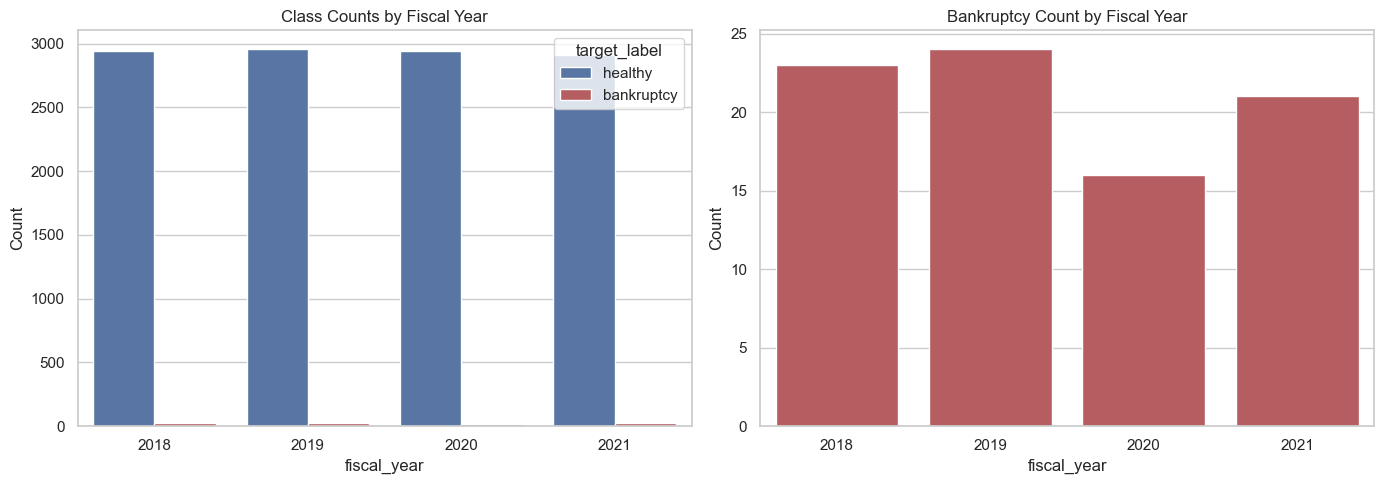

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=eda_df,
    x="fiscal_year",
    hue="target_label",
    ax=axes[0],
    palette={"healthy": "#4c72b0", "bankruptcy": "#c44e52"},
)
axes[0].set_title("Class Counts by Fiscal Year")
axes[0].set_xlabel("fiscal_year")
axes[0].set_ylabel("Count")

sns.barplot(
    data=bankruptcy_year_summary.reset_index(),
    x="fiscal_year",
    y="bankruptcies",
    ax=axes[1],
    color="#c44e52",
)
axes[1].set_title("Bankruptcy Count by Fiscal Year")
axes[1].set_xlabel("fiscal_year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../images/class_counts_by_year.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.5 Ratio Correlations

The pre-calculated ratios are already transformations of the raw balance sheet numbers, 
so some correlation between them is expected (e.g., leverage and debt_to_assets both capture debt load). 
The right panel shows the direct linear correlation of each ratio with the bankruptcy label.

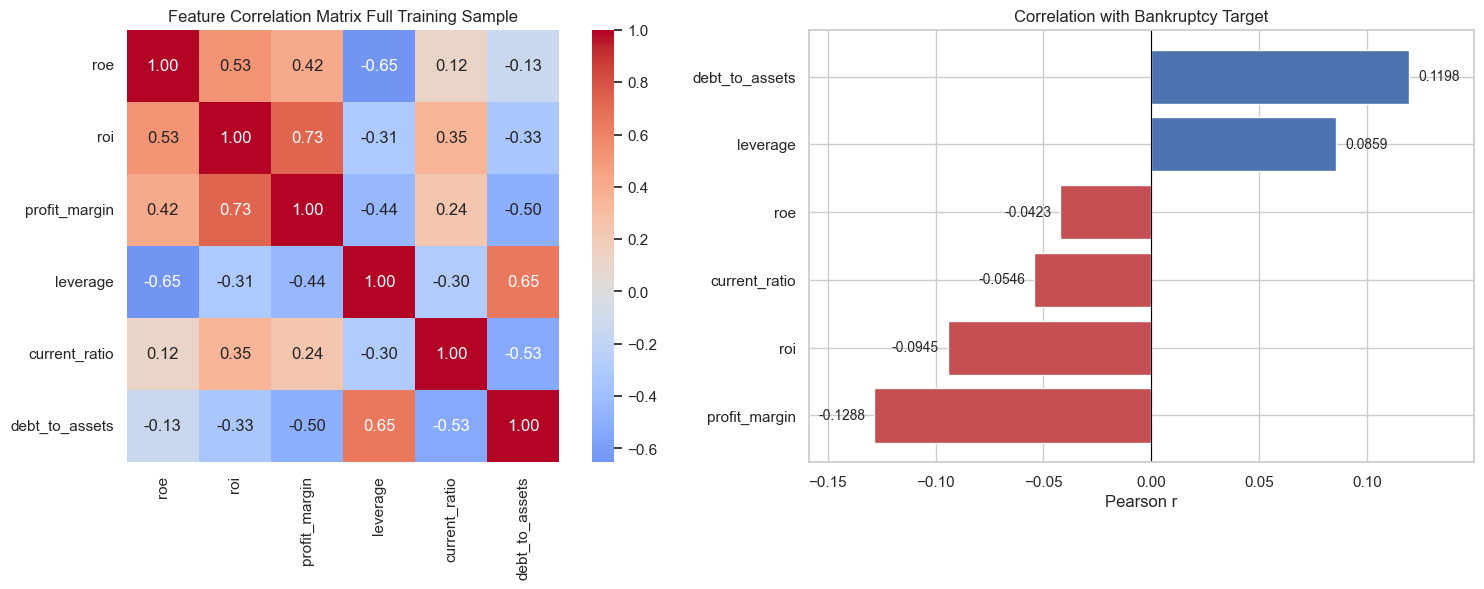

In [9]:
corr_features = ["roe", "roi", "profit_margin", "leverage", "current_ratio", "debt_to_assets"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feature_corr = eda_df[corr_features].corr(numeric_only=True)
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Feature Correlation Matrix Full Training Sample")

target_corr = (
    eda_df[corr_features + ["bankruptcy_next_year"]]
    .corr(numeric_only=True)["bankruptcy_next_year"]
    .drop("bankruptcy_next_year")
    .sort_values()
)
bar_colors = ["#c44e52" if v < 0 else "#4c72b0" for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=bar_colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with Bankruptcy Target")
axes[1].set_xlabel("Pearson r")
axes[1].set_xlim(target_corr.min() - 0.03, target_corr.max() + 0.03)
for i, (feature, value) in enumerate(target_corr.items()):
    x_pos = value + 0.004 if value >= 0 else value - 0.004
    axes[1].text(x_pos, i, f"{value:.4f}", va="center", ha="left" if value >= 0 else "right", fontsize=10)

plt.tight_layout()
plt.savefig("../images/ratio_correlations.png", bbox_inches="tight", dpi=150)
plt.show()


### 2.6 Financial Ratios by Bankruptcy Status

Next we check which ratios separate bankrupt firms from healthy ones. Box plots are clipped at the 1st and 99th percentiles 
to prevent extreme outliers from compressing the main distribution into a thin line.

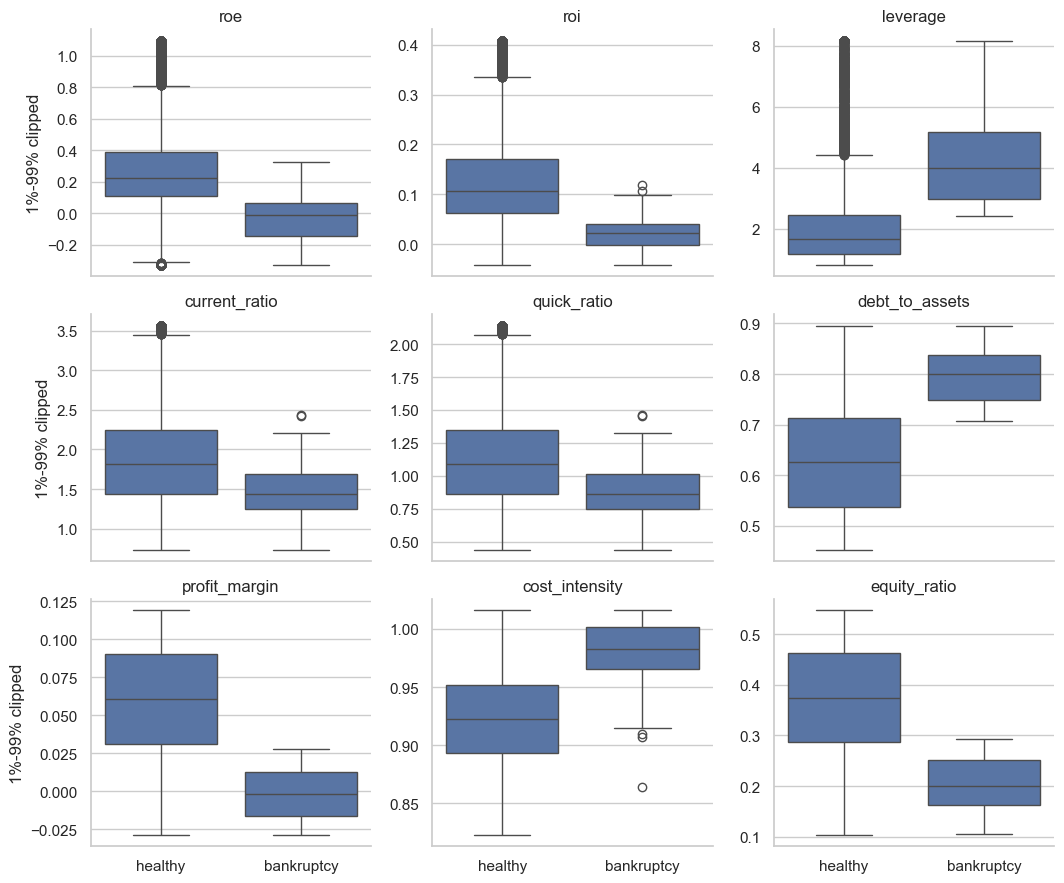

In [10]:
ratio_features = [
    "roe",
    "roi",
    "leverage",
    "current_ratio",
    "quick_ratio",
    "debt_to_assets",
    "profit_margin",
    "cost_intensity",
    "equity_ratio",
]

ratio_plot_df = eda_df.melt(
    id_vars=["bankruptcy_next_year", "target_label"],
    value_vars=ratio_features,
    var_name="feature",
    value_name="value",
)
ratio_plot_df["value_clip"] = ratio_plot_df.groupby("feature")["value"].transform(
    lambda s: s.clip(s.quantile(0.01), s.quantile(0.99))
)

g = sns.FacetGrid(
    ratio_plot_df,
    col="feature",
    col_wrap=3,
    sharey=False,
    height=3.0,
    aspect=1.2,
)
g.map_dataframe(
    sns.boxplot,
    x="target_label",
    y="value_clip",
    order=["healthy", "bankruptcy"],
)
g.set_axis_labels("", "1%-99% clipped")
g.set_titles("{col_name}")
plt.tight_layout()
g.savefig("../images/ratio_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.7 Deterioration Before Bankruptcy

Static snapshots of financial ratios only tell part of the story. A company sitting at debt_to_assets = 0.8 
that was at 0.6 last year is in a very different position than one that's been at 0.8 for four consecutive years. 
This checks whether bankrupt companies were already trending downward in profitability and leverage 
before the bankruptcy event, and by how much.

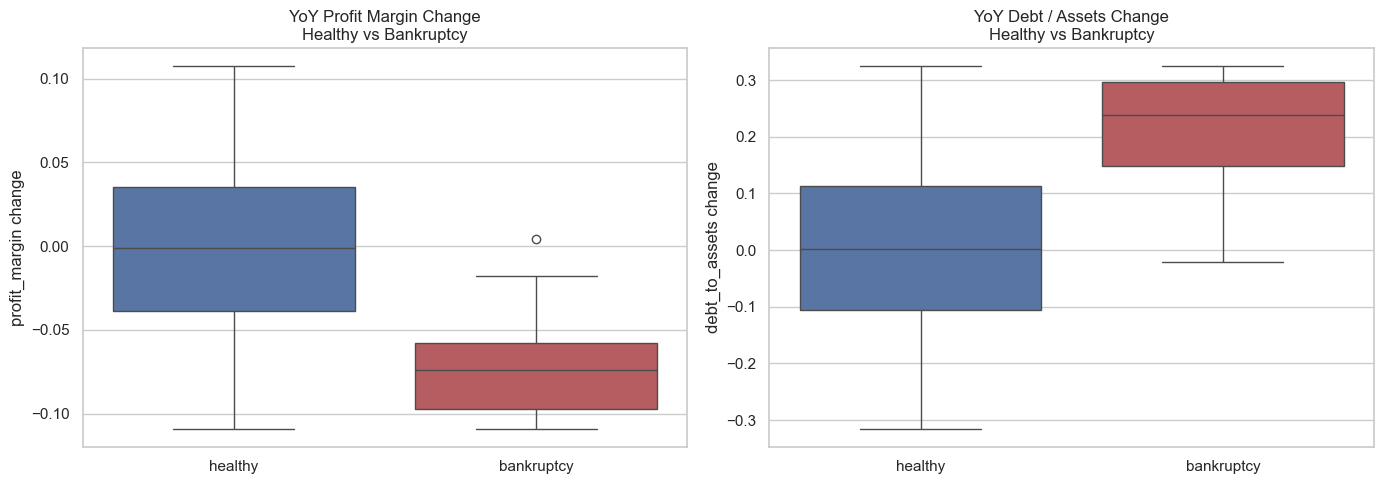

,profit_margin_yoy_change,debt_to_assets_yoy_change
bankruptcy_next_year,,
healthy,-0.0010,0.0013
bankruptcy,-0.0737,0.2385


In [11]:
deterioration_df = eda_df.sort_values(["company_id", "fiscal_year"]).assign(
    profit_margin_yoy_change=lambda df: df.groupby("company_id")["profit_margin"].diff(),
    debt_to_assets_yoy_change=lambda df: df.groupby("company_id")["debt_to_assets"].diff(),
    target_label=lambda df: df["bankruptcy_next_year"].map({0: "healthy", 1: "bankruptcy"}),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature, title, ylabel in [
    (axes[0], "profit_margin_yoy_change", "YoY Profit Margin Change\nHealthy vs Bankruptcy", "profit_margin change"),
    (axes[1], "debt_to_assets_yoy_change", "YoY Debt / Assets Change\nHealthy vs Bankruptcy", "debt_to_assets change"),
]:
    plot_df = deterioration_df[[feature, "target_label"]].dropna()
    lower = plot_df[feature].quantile(0.02)
    upper = plot_df[feature].quantile(0.98)
    plot_df = plot_df.assign(**{feature: plot_df[feature].clip(lower, upper)})
    sns.boxplot(
        data=plot_df,
        x="target_label",
        y=feature,
        order=["healthy", "bankruptcy"],
        palette={"healthy": "#4c72b0", "bankruptcy": "#c44e52"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig("../images/temporal_deterioration.png", bbox_inches="tight", dpi=150)
plt.show()

deterioration_summary = (
    deterioration_df.groupby("bankruptcy_next_year")[["profit_margin_yoy_change", "debt_to_assets_yoy_change"]]
    .median()
    .rename(index={0: "healthy", 1: "bankruptcy"})
)
display(deterioration_summary.round(4))



### 2.8 Interest Coverage Thresholds

Interest coverage (operating income / financial expenses) measures how comfortably a company can service its debt. 
A ratio below 1 means operating profit doesn't cover the interest bill. Below 0 means the company is 
already losing money at the operating level. These are hard breakpoints: the bankruptcy rate doesn't 
just gradually increase, it tends to jump sharply once coverage falls below key thresholds.

,bankruptcy_rate,bankruptcies,rows
ic_bucket,,,
<0,0.0583,25,429
0-0.5,0.0243,6,247
0.5-1,0.0450,15,333
1-2,0.0331,30,907
2-5,0.0018,7,3928
>5,0.0002,1,5984


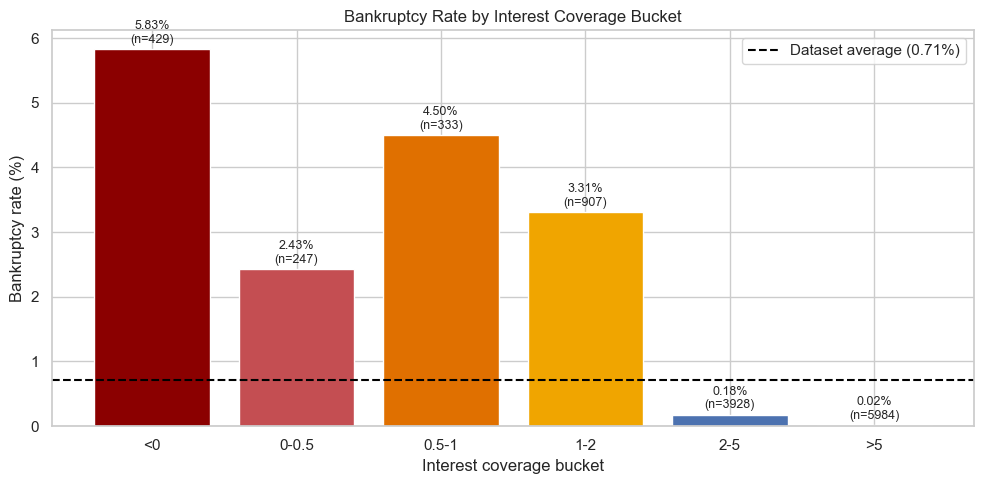

In [12]:
interest_coverage_eda = eda_safe_divide(eda_df["operating_income"], eda_df["financial_expenses"])
ic_bins = [-np.inf, 0, 0.5, 1.0, 2.0, 5.0, np.inf]
ic_labels = ["<0", "0-0.5", "0.5-1", "1-2", "2-5", ">5"]
ic_bucket = pd.cut(interest_coverage_eda, bins=ic_bins, labels=ic_labels)

ic_bucket_summary = (
    pd.DataFrame({"ic_bucket": ic_bucket, "bankruptcy_next_year": eda_df["bankruptcy_next_year"]})
    .groupby("ic_bucket", observed=True)["bankruptcy_next_year"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "bankruptcy_rate", "sum": "bankruptcies", "count": "rows"})
)
display(ic_bucket_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#8b0000", "#c44e52", "#e07000", "#f0a500", "#4c72b0", "#2196f3"]
bars = ax.bar(
    ic_bucket_summary.index.astype(str),
    ic_bucket_summary["bankruptcy_rate"] * 100,
    color=colors[:len(ic_bucket_summary)],
)
avg_rate = train_df["bankruptcy_next_year"].mean() * 100
ax.axhline(avg_rate, color="black", linestyle="--", label=f"Dataset average ({avg_rate:.2f}%)")
ax.set_xlabel("Interest coverage bucket")
ax.set_ylabel("Bankruptcy rate (%)")
ax.set_title("Bankruptcy Rate by Interest Coverage Bucket")
ax.legend()
for bar, row in zip(bars, ic_bucket_summary.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{row.bankruptcy_rate * 100:.2f}%\n(n={row.rows})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig("../images/interest_coverage.png", bbox_inches="tight", dpi=150)
plt.show()



### 2.9 Thin Margins and Heavy Debt

Many bankruptcies in this dataset don't look like obvious collapses. They're large companies operating 
on very thin profit margins while carrying significant debt. That combination is fragile: a small 
revenue drop or unexpected cost spike is enough to tip them over. Margin and debt together are 
more discriminating than either dimension alone.

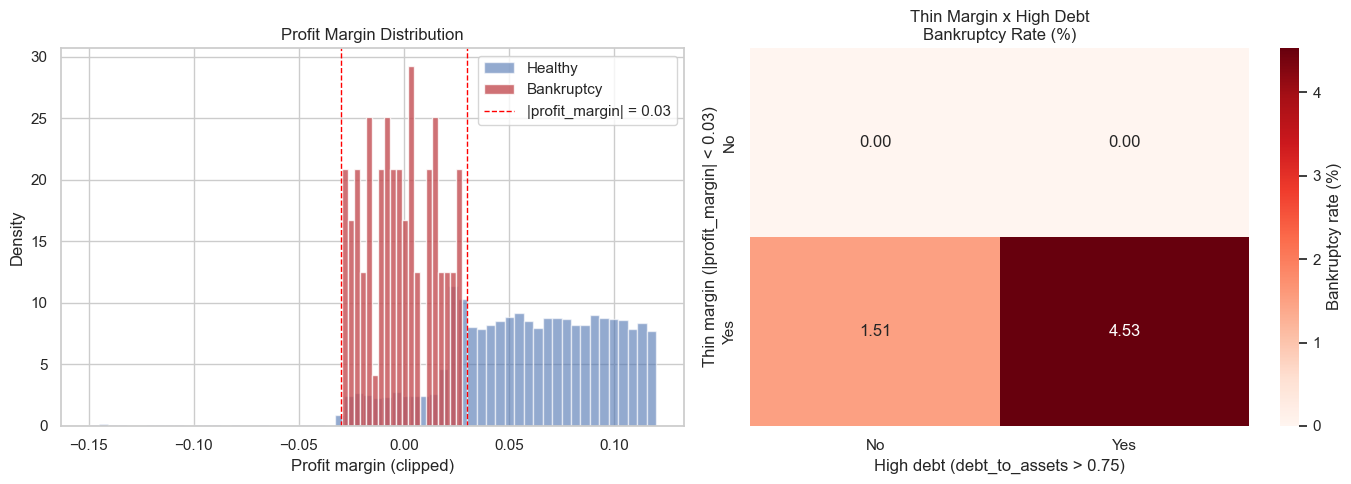

,thin_margin,high_debt,bankruptcy_rate,rows
0,No,No,0.000000,8926
1,No,Yes,0.000000,78
2,Yes,No,1.510989,1456
3,Yes,Yes,4.532164,1368


In [13]:
target_label = eda_df["bankruptcy_next_year"].map({0: "healthy", 1: "bankruptcy"})
pm_clip = eda_df["profit_margin"].clip(-0.15, 0.25)
thin_margin_flag = eda_df["profit_margin"].abs().lt(0.03)
high_debt_flag = eda_df["debt_to_assets"].gt(0.75)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    pm_clip[target_label == "healthy"].dropna(),
    bins=60,
    alpha=0.6,
    color="#4c72b0",
    density=True,
    label="Healthy",
)
axes[0].hist(
    pm_clip[target_label == "bankruptcy"].dropna(),
    bins=20,
    alpha=0.8,
    color="#c44e52",
    density=True,
    label="Bankruptcy",
)
axes[0].axvline(-0.03, color="red", linestyle="--", linewidth=1)
axes[0].axvline(0.03, color="red", linestyle="--", linewidth=1, label="|profit_margin| = 0.03")
axes[0].set_xlabel("Profit margin (clipped)")
axes[0].set_ylabel("Density")
axes[0].set_title("Profit Margin Distribution")
axes[0].legend()

quadrant_rows = []
for thin in [0, 1]:
    for hd in [0, 1]:
        mask = thin_margin_flag.eq(bool(thin)) & high_debt_flag.eq(bool(hd))
        sub = eda_df.loc[mask, "bankruptcy_next_year"]
        quadrant_rows.append(
            {
                "thin_margin": "Yes" if thin else "No",
                "high_debt": "Yes" if hd else "No",
                "bankruptcy_rate": sub.mean() * 100 if len(sub) else 0.0,
                "rows": int(len(sub)),
            }
        )

quadrant_df = pd.DataFrame(quadrant_rows)
heatmap_df = quadrant_df.pivot(index="thin_margin", columns="high_debt", values="bankruptcy_rate")
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={"label": "Bankruptcy rate (%)"},
    ax=axes[1],
)
axes[1].set_title("Thin Margin x High Debt\nBankruptcy Rate (%)")
axes[1].set_xlabel("High debt (debt_to_assets > 0.75)")
axes[1].set_ylabel("Thin margin (|profit_margin| < 0.03)")

plt.tight_layout()
plt.savefig("../images/thin_margin_high_debt.png", bbox_inches="tight", dpi=150)
plt.show()

display(quadrant_df)



### 2.10 Sector and Regional Patterns

Bankruptcy doesn't hit all sectors and regions equally. Some industries are structurally more 
leveraged (construction, wholesale trade), while others are more stable. Geographic concentration 
of distress can also reflect regional economic conditions beyond what firm-level financials capture.

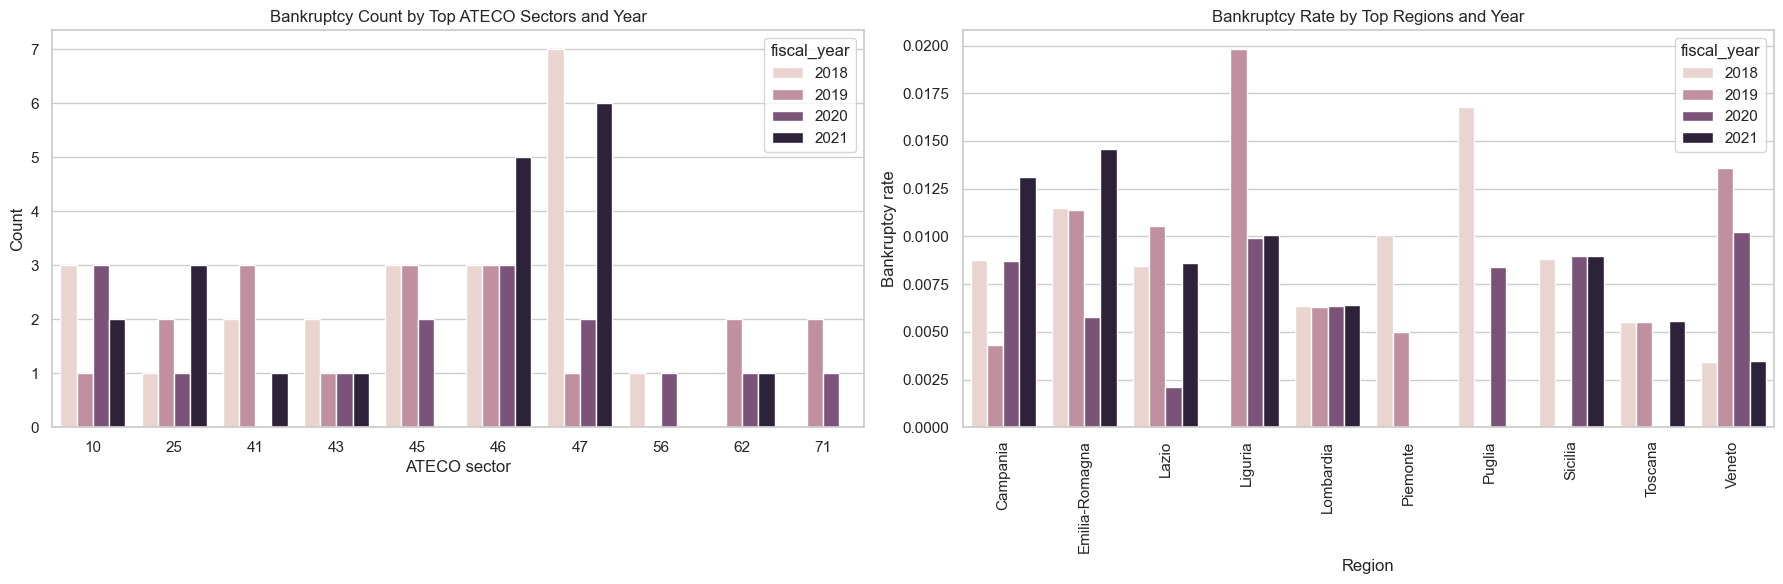

In [14]:
top_sectors = eda_df["ateco_sector"].value_counts().nlargest(10).index
top_regions = eda_df["region"].value_counts().nlargest(10).index

sector_year_count = (
    eda_df[eda_df["ateco_sector"].isin(top_sectors)]
    .groupby(["fiscal_year", "ateco_sector"])["bankruptcy_next_year"]
    .sum()
    .reset_index()
)

region_year_rate = (
    eda_df[eda_df["region"].isin(top_regions)]
    .groupby(["fiscal_year", "region"])["bankruptcy_next_year"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=sector_year_count,
    x="ateco_sector",
    y="bankruptcy_next_year",
    hue="fiscal_year",
    ax=axes[0],
)
axes[0].set_title("Bankruptcy Count by Top ATECO Sectors and Year")
axes[0].set_xlabel("ATECO sector")
axes[0].set_ylabel("Count")

sns.barplot(
    data=region_year_rate,
    x="region",
    y="bankruptcy_next_year",
    hue="fiscal_year",
    ax=axes[1],
)
axes[1].set_title("Bankruptcy Rate by Top Regions and Year")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Bankruptcy rate")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("../images/sector_region_patterns.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.11 Scale and Outlier Behavior

The dataset spans tiny SMEs and large enterprises, across several orders of magnitude in revenue and assets. 
A symlog scale keeps the full distribution visible without hiding the small-company mass. 
The per-class breakdown shows that bankrupt and healthy companies overlap substantially in scale, so size alone does not explain bankruptcy.

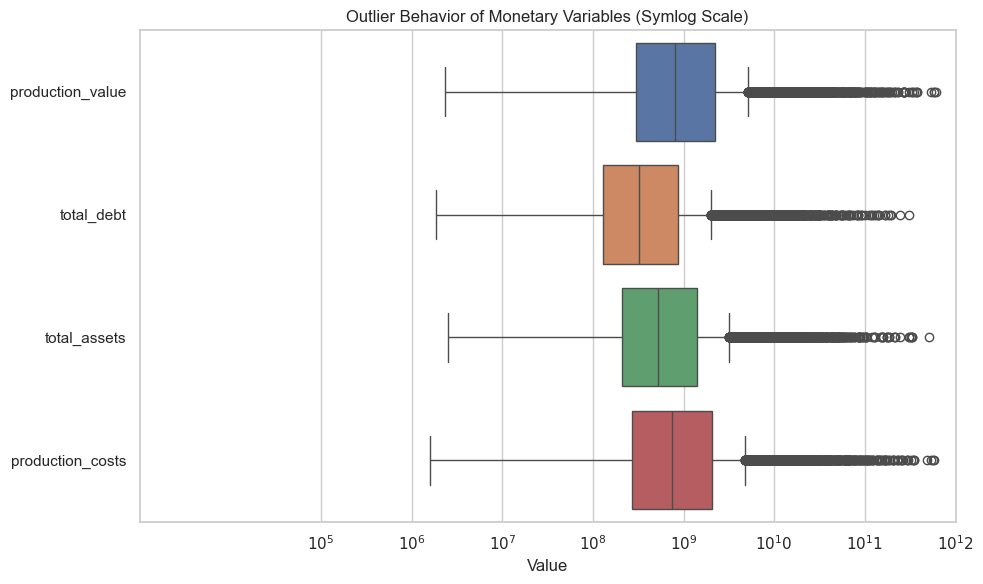

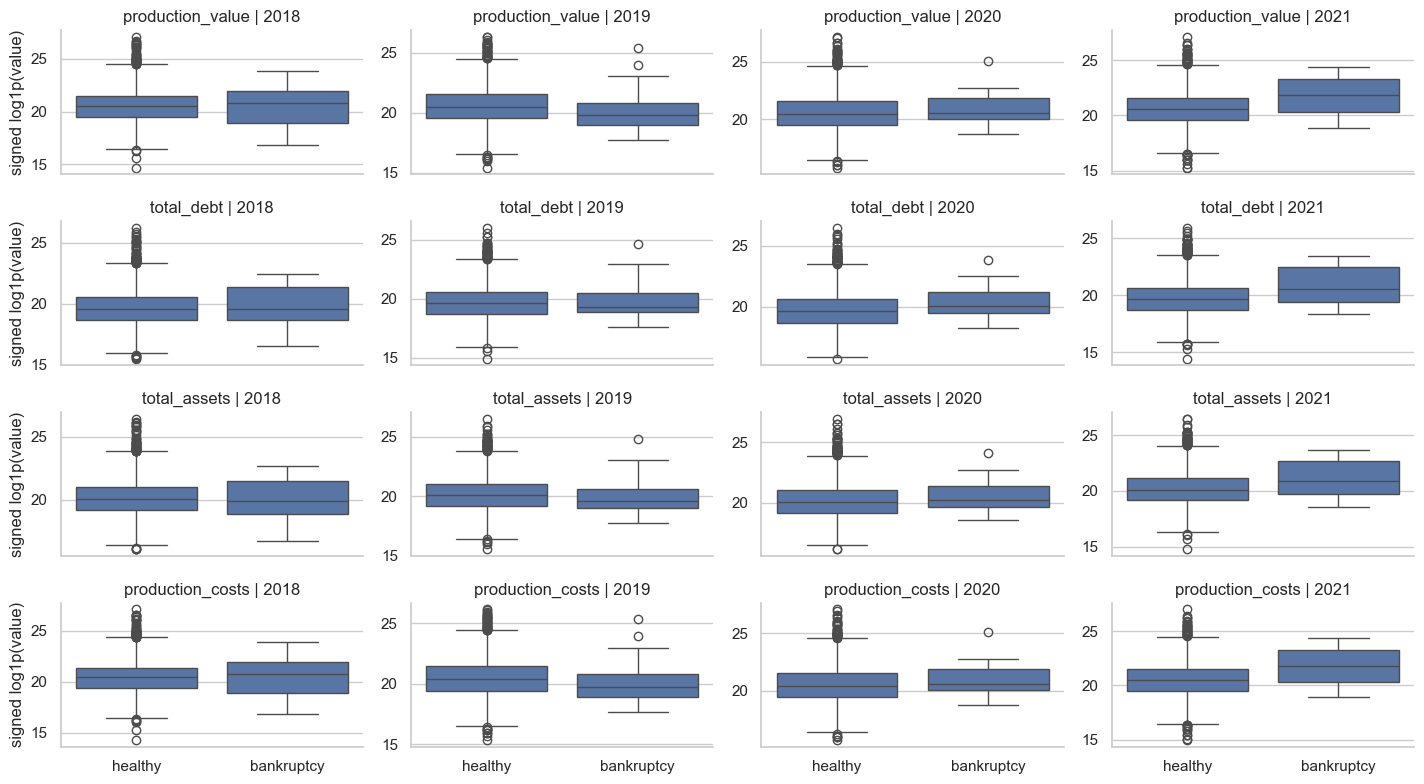

In [15]:
monetary_cols = [
    "production_value",
    "total_debt",
    "total_assets",
    "production_costs",
]

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=eda_df[monetary_cols], orient="h")
ax.set_xscale("symlog", linthresh=1e3)
ax.set_xlim(1e3, 1e12)
x_ticks = [10 ** power for power in range(5, 13)]
ax.set_xticks(x_ticks)
ax.set_xticklabels([rf"$10^{power}$" for power in range(5, 13)])
ax.set_title("Outlier Behavior of Monetary Variables (Symlog Scale)")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig("../images/monetary_outliers.png", bbox_inches="tight", dpi=150)
plt.show()

monetary_plot_df = eda_df.melt(
    id_vars=["fiscal_year", "target_label"],
    value_vars=monetary_cols,
    var_name="feature",
    value_name="value",
)
monetary_plot_df["signed_log_value"] = np.sign(monetary_plot_df["value"]) * np.log1p(monetary_plot_df["value"].abs())

g = sns.FacetGrid(
    monetary_plot_df,
    row="feature",
    col="fiscal_year",
    sharey=False,
    height=2.0,
    aspect=1.8,
)
g.map_dataframe(
    sns.boxplot,
    x="target_label",
    y="signed_log_value",
    order=["healthy", "bankruptcy"],
)
g.set_axis_labels("", "signed log1p(value)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.tight_layout()
g.savefig("../images/monetary_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.12 Equity Gap Signals

Shareholders' equity changes between years for two reasons: retained profit/loss, and external capital events 
(fresh equity injections, owner withdrawals, write-downs). When the actual change is much larger or smaller 
than net profit/loss alone explains, something unusual happened. During COVID, these signals became 
especially pronounced, because government support and emergency capital injections created patterns worth tracking.

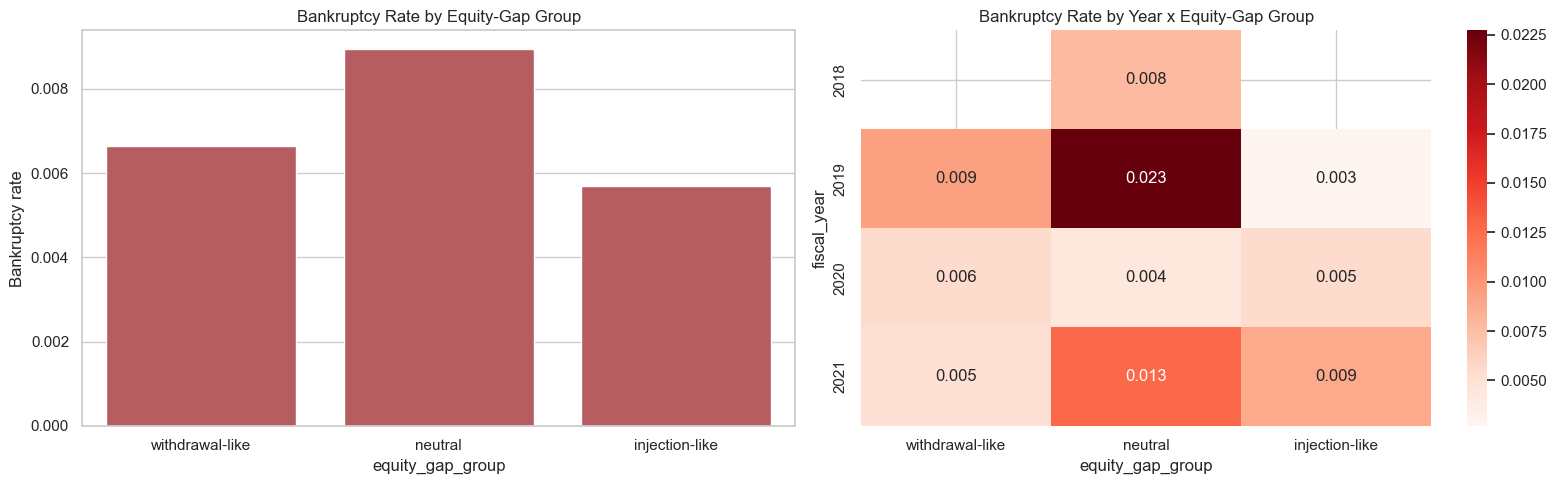

Equity-gap proxy summary for bankruptcy target:


,equity_gap_group,n_obs,bankruptcy_rate,shock_rate,median_equity_gap_pct_assets
0,withdrawal-like,4807,0.006657,1.0,-0.727233
1,neutral,3690,0.008943,0.0,0.000065
2,injection-like,3331,0.005704,1.0,0.190543


In [16]:
shareholders_equity_lag1 = eda_df.groupby("company_id")["shareholders_equity"].shift(1)
equity_expected_from_profit = shareholders_equity_lag1 + eda_df["net_profit_loss"]
equity_gap = eda_df["shareholders_equity"] - equity_expected_from_profit
equity_gap_pct_assets = eda_safe_divide(equity_gap, eda_df["total_assets"])

EQUITY_GAP_ASSET_THRESHOLD = 0.04

equity_injection_flag = (equity_gap_pct_assets >= EQUITY_GAP_ASSET_THRESHOLD).astype(int)
equity_withdrawal_flag = (equity_gap_pct_assets <= -EQUITY_GAP_ASSET_THRESHOLD).astype(int)
equity_shock_flag = (equity_gap_pct_assets.abs() >= EQUITY_GAP_ASSET_THRESHOLD).astype(int)

equity_gap_group = np.select(
    [
        equity_injection_flag == 1,
        equity_withdrawal_flag == 1,
    ],
    ["injection-like", "withdrawal-like"],
    default="neutral",
)

group_order = ["withdrawal-like", "neutral", "injection-like"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

equity_group_summary = (
    pd.DataFrame({
        "company_id": eda_df["company_id"],
        "bankruptcy_next_year": eda_df["bankruptcy_next_year"],
        "equity_shock_flag": equity_shock_flag,
        "equity_gap_pct_assets": equity_gap_pct_assets,
        "equity_gap_group": equity_gap_group,
    })
    .groupby("equity_gap_group")
    .agg(
        n_obs=("company_id", "size"),
        bankruptcy_rate=("bankruptcy_next_year", "mean"),
        shock_rate=("equity_shock_flag", "mean"),
        median_equity_gap_pct_assets=("equity_gap_pct_assets", "median"),
    )
    .reindex(group_order)
    .reset_index()
)

sns.barplot(
    data=equity_group_summary,
    x="equity_gap_group",
    y="bankruptcy_rate",
    order=group_order,
    ax=axes[0],
    color="#c44e52",
)
axes[0].set_title("Bankruptcy Rate by Equity-Gap Group")
axes[0].set_xlabel("equity_gap_group")
axes[0].set_ylabel("Bankruptcy rate")

year_group_pivot = (
    pd.DataFrame({
        "fiscal_year": eda_df["fiscal_year"],
        "equity_gap_group": equity_gap_group,
        "bankruptcy_next_year": eda_df["bankruptcy_next_year"],
    })
    .groupby(["fiscal_year", "equity_gap_group"])["bankruptcy_next_year"]
    .mean()
    .unstack("equity_gap_group")
    .reindex(columns=group_order)
)

sns.heatmap(
    year_group_pivot,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    ax=axes[1],
)
axes[1].set_title("Bankruptcy Rate by Year x Equity-Gap Group")
axes[1].set_xlabel("equity_gap_group")
axes[1].set_ylabel("fiscal_year")

plt.tight_layout()
plt.savefig("../images/equity_gap.png", bbox_inches="tight", dpi=150)
plt.show()

print("Equity-gap proxy summary for bankruptcy target:")
display(equity_group_summary)

### 2.13 Short-Term Debt Pressure

Total leverage is one thing, but maturity timing matters too. Short-term debt relative to operating income 
captures immediate refinancing risk: even a modestly levered firm can face a crisis if a large debt 
tranche comes due while operating income is temporarily weak. This ratio targets that near-term pressure 
rather than the overall balance sheet picture.

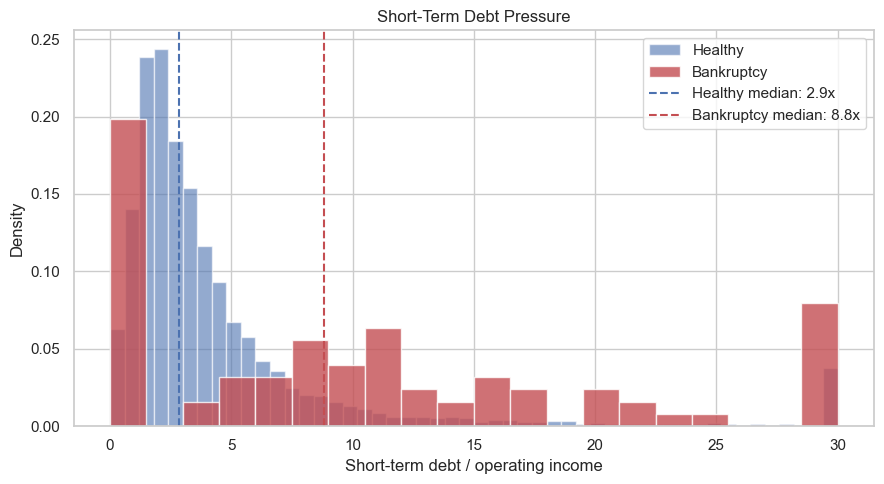

In [17]:
short_debt_pressure_clip = eda_safe_divide(eda_df["short_term_debt"], eda_df["operating_income"]).clip(0, 30)

bankrupt_sdp = short_debt_pressure_clip[eda_df["bankruptcy_next_year"] == 1].dropna()
healthy_sdp = short_debt_pressure_clip[eda_df["bankruptcy_next_year"] == 0].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(healthy_sdp, bins=50, alpha=0.6, color="#4c72b0", density=True, label="Healthy")
ax.hist(bankrupt_sdp, bins=20, alpha=0.8, color="#c44e52", density=True, label="Bankruptcy")
if not healthy_sdp.empty:
    ax.axvline(
        healthy_sdp.median(),
        color="#4c72b0",
        linestyle="--",
        label=f"Healthy median: {healthy_sdp.median():.1f}x",
    )
if not bankrupt_sdp.empty:
    ax.axvline(
        bankrupt_sdp.median(),
        color="#c44e52",
        linestyle="--",
        label=f"Bankruptcy median: {bankrupt_sdp.median():.1f}x",
    )
ax.set_xlabel("Short-term debt / operating income")
ax.set_ylabel("Density")
ax.set_title("Short-Term Debt Pressure")
ax.legend()
plt.tight_layout()
plt.savefig("../images/short_debt_pressure.png", bbox_inches="tight", dpi=150)
plt.show()



### 2.14 EDA Summary

Across all the analyses above, a consistent pattern emerges. The table below ties together the strongest 
observed signals, directly comparing bankrupt and healthy companies across each dimension.

In [18]:
interest_coverage_eda = eda_safe_divide(
    eda_df["operating_income"],
    eda_df["financial_expenses"],
)
thin_margin_flag = eda_df["profit_margin"].abs().lt(0.03).astype(int)
profit_margin_yoy_change = eda_df.groupby("company_id")["profit_margin"].diff()
short_debt_pressure_eda = eda_safe_divide(
    eda_df["short_term_debt"],
    eda_df["operating_income"],
)

healthy_mask = eda_df["bankruptcy_next_year"] == 0
bankrupt_mask = eda_df["bankruptcy_next_year"] == 1

summary_rows = [
    {
        "characteristic": "Absolute thin margin share (|profit_margin| < 3%)",
        "healthy": float(thin_margin_flag.loc[healthy_mask].mean()),
        "bankruptcy": float(thin_margin_flag.loc[bankrupt_mask].mean()),
        "format": "pct",
    },
    {
        "characteristic": "Debt-to-assets median",
        "healthy": float(eda_df.loc[healthy_mask, "debt_to_assets"].median()),
        "bankruptcy": float(eda_df.loc[bankrupt_mask, "debt_to_assets"].median()),
        "format": "num",
    },
    {
        "characteristic": "Interest coverage median",
        "healthy": float(interest_coverage_eda.loc[healthy_mask].median()),
        "bankruptcy": float(interest_coverage_eda.loc[bankrupt_mask].median()),
        "format": "num",
    },
    {
        "characteristic": "YoY profit-margin change median",
        "healthy": float(profit_margin_yoy_change.loc[healthy_mask].median()),
        "bankruptcy": float(profit_margin_yoy_change.loc[bankrupt_mask].median()),
        "format": "num",
    },
    {
        "characteristic": "Short-debt pressure median",
        "healthy": float(short_debt_pressure_eda.loc[healthy_mask].median()),
        "bankruptcy": float(short_debt_pressure_eda.loc[bankrupt_mask].median()),
        "format": "num",
    },
]

summary_table = pd.DataFrame(summary_rows)

def _format_row(row):
    if row["format"] == "pct":
        return pd.Series({
            "healthy": f"{row['healthy'] * 100:.2f}%",
            "bankruptcy": f"{row['bankruptcy'] * 100:.2f}%",
        })
    return pd.Series({
        "healthy": f"{row['healthy']:.4f}",
        "bankruptcy": f"{row['bankruptcy']:.4f}",
    })

formatted_vals = summary_table.apply(_format_row, axis=1)
summary_table["healthy"] = formatted_vals["healthy"]
summary_table["bankruptcy"] = formatted_vals["bankruptcy"]
display(summary_table[["characteristic", "healthy", "bankruptcy"]])

,characteristic,healthy,bankruptcy
0,Absolute thin margin share (|profit_margin| < 3%),23.33%,100.00%
1,Debt-to-assets median,0.6264,0.8002
2,Interest coverage median,5.1064,0.8944
3,YoY profit-margin change median,-0.0010,-0.0737
4,Short-debt pressure median,2.8658,8.8292


## 3. Feature Engineering

Raw financial ratios capture the current state, but they miss dynamics. A company with 
debt_to_assets = 0.8 that was 0.6 last year is fundamentally different from one that's 
been at 0.8 for four years. The features here focus on:

- **Temporal deterioration**: year-over-year changes in key ratios
- **Two-year trend flags**: detecting sustained worsening vs. one-year noise
- **Distress signal counts**: combining multiple weak signals into a composite score
- **Altman Z-score proxy**: adapted to the available features from the original bankruptcy formula
- **Interest coverage and loss severity**: quantifying how bad the operating shortfall is
- **Equity-gap features**: flags when equity changes don't match reported profit/loss, 
captures unusual capital events (injections, withdrawals, COVID-era support)
- **Sector-relative position**: where the company stands vs. its industry peers
- **Structural missingness flags**: missing `roe` and `leverage` values are linked to negative equity, 
so flagging them preserves information that a simple imputation would miss


In [19]:
safe_divide = eda_safe_divide
def signed_log1p(series):
    return np.sign(series) * np.log1p(np.abs(series))


def _temporal_fit_mask(df, year, source_col="_row_source"):
    train_mask = df[source_col].eq("train")
    prior_train_mask = train_mask & df["fiscal_year"].lt(year)
    if prior_train_mask.any():
        return prior_train_mask

    earliest_train_year = df.loc[train_mask, "fiscal_year"].min()
    if year == earliest_train_year:
        return train_mask & df["fiscal_year"].eq(year)
    return prior_train_mask


def temporal_group_median(df, value_col, group_cols):
    group_cols = [col for col in group_cols if col != "fiscal_year"]
    out = pd.Series(np.nan, index=df.index, dtype="float64")

    for year in sorted(df["fiscal_year"].dropna().unique()):
        row_mask = df["fiscal_year"].eq(year)
        fit_mask = _temporal_fit_mask(df, year)
        if not fit_mask.any():
            continue

        if not group_cols:
            out.loc[row_mask] = df.loc[fit_mask, value_col].median()
            continue

        stats = (
            df.loc[fit_mask, group_cols + [value_col]]
            .groupby(group_cols, dropna=False)[value_col]
            .median()
            .rename("_median")
            .reset_index()
        )
        mapped = (
            df.loc[row_mask, group_cols]
            .reset_index()
            .merge(stats, on=group_cols, how="left")
            .set_index("index")["_median"]
        )
        out.loc[mapped.index] = mapped
    return out


def assign_temporal_size_tier(df, value_col="production_value", n_tiers=10):
    tier = pd.Series(np.nan, index=df.index, dtype="float64")

    for year in sorted(df["fiscal_year"].dropna().unique()):
        row_mask = df["fiscal_year"].eq(year)
        fit_mask = _temporal_fit_mask(df, year)
        fit_values = df.loc[fit_mask, value_col].dropna().sort_values().to_numpy()
        if len(fit_values) == 0:
            continue

        values = df.loc[row_mask, value_col]
        percentile_rank = np.searchsorted(fit_values, values, side="right") / len(fit_values)
        tier.loc[row_mask] = np.clip(np.floor(percentile_rank * n_tiers) + 1, 1, n_tiers)
    return tier


def hierarchical_ratio_impute(df, value_col, company_group, peer_groupings):
    filled = df[value_col].copy()
    source = pd.Series("observed", index=df.index, dtype="object")

    lag1 = company_group[value_col].shift(1)
    use_lag1 = filled.isna() & lag1.notna()
    filled.loc[use_lag1] = lag1.loc[use_lag1]
    source.loc[use_lag1] = "own_lag1"

    lag2 = company_group[value_col].shift(2)
    use_lag2 = filled.isna() & lag2.notna()
    filled.loc[use_lag2] = lag2.loc[use_lag2]
    source.loc[use_lag2] = "own_lag2"

    for grouping, label in peer_groupings:
        peer_median = temporal_group_median(df, value_col, grouping)
        use_peer = filled.isna() & peer_median.notna()
        filled.loc[use_peer] = peer_median.loc[use_peer]
        source.loc[use_peer] = label

    overall_median = df.loc[df["_row_source"].eq("train"), value_col].median()
    use_overall = filled.isna()
    filled.loc[use_overall] = overall_median
    source.loc[use_overall] = "overall_median"

    return filled, source


def build_panel_features(train_df, test_df):
    domain_caps = {
        "roe": (-5.0, 5.0),
        "leverage": (-20.0, 20.0),
        "current_ratio": (0.0, 10.0),
        "interest_coverage_proxy": (-50.0, 50.0),
    }
    extreme_thresholds = {
        "roe": 2.0,
        "leverage": 10.0,
        "current_ratio": 10.0,
        "interest_coverage_proxy": 30.0,
    }

    full_df = pd.concat(
        [
            train_df.assign(_row_source="train"),
            test_df.assign(_row_source="test"),
        ],
        axis=0,
        sort=False,
    ).sort_values(["company_id", "fiscal_year"]).reset_index(drop=True)

    province_series = full_df["province"].astype("string").str.strip()
    province_missing_mask = province_series.isna() | province_series.str.upper().eq("NA").fillna(False)
    full_df["province_missing"] = province_missing_mask.astype(int)
    full_df.loc[province_missing_mask, "province"] = "Napoli"

    grp = full_df.groupby("company_id")

    full_df["shareholders_equity_zero_flag"] = full_df["shareholders_equity"].eq(0).fillna(False).astype(int)
    full_df["roe_missing"] = full_df["roe"].isna().astype(int)
    full_df["leverage_missing"] = full_df["leverage"].isna().astype(int)
    full_df["roe_denominator_zero_flag"] = (
        full_df["roe_missing"].eq(1) & full_df["shareholders_equity_zero_flag"].eq(1)
    ).astype(int)
    full_df["leverage_denominator_zero_flag"] = (
        full_df["leverage_missing"].eq(1) & full_df["shareholders_equity_zero_flag"].eq(1)
    ).astype(int)

    ratio_peer_groupings = [
        (["fiscal_year", "ateco_sector", "region"], "peer_year_sector_region"),
        (["fiscal_year", "ateco_sector"], "peer_year_sector"),
        (["fiscal_year", "region"], "peer_year_region"),
        (["fiscal_year"], "peer_year"),
    ]
    full_df["roe"], full_df["roe_imputation_source"] = hierarchical_ratio_impute(
        full_df,
        "roe",
        grp,
        ratio_peer_groupings,
    )
    full_df["leverage"], full_df["leverage_imputation_source"] = hierarchical_ratio_impute(
        full_df,
        "leverage",
        grp,
        ratio_peer_groupings,
    )
    full_df["roe_history_imputed_flag"] = full_df["roe_imputation_source"].isin(["own_lag1", "own_lag2"]).astype(int)
    full_df["roe_peer_imputed_flag"] = full_df["roe_imputation_source"].str.startswith("peer_").fillna(False).astype(int)
    full_df["leverage_history_imputed_flag"] = full_df["leverage_imputation_source"].isin(["own_lag1", "own_lag2"]).astype(int)
    full_df["leverage_peer_imputed_flag"] = full_df["leverage_imputation_source"].str.startswith("peer_").fillna(False).astype(int)

    full_df["working_capital"] = full_df["current_assets"] - full_df["short_term_debt"]
    full_df["equity_ratio_calc"] = safe_divide(full_df["shareholders_equity"], full_df["total_assets"])
    full_df["debt_to_equity_calc"] = safe_divide(full_df["total_debt"], full_df["shareholders_equity"])
    full_df["operating_margin"] = safe_divide(full_df["operating_income"], full_df["production_value"])
    full_df["interest_coverage_proxy"] = safe_divide(full_df["operating_income"], full_df["financial_expenses"])
    full_df["debt_gap"] = full_df["total_debt"] - full_df["current_assets"]
    full_df["working_capital_to_assets"] = safe_divide(full_df["working_capital"], full_df["total_assets"])
    full_df["asset_turnover"] = safe_divide(full_df["production_value"], full_df["total_assets"])
    full_df["net_profit_to_assets"] = safe_divide(full_df["net_profit_loss"], full_df["total_assets"])
    full_df["operating_income_to_assets"] = safe_divide(full_df["operating_income"], full_df["total_assets"])
    full_df["book_equity_to_debt"] = safe_divide(full_df["shareholders_equity"], full_df["total_debt"])
    full_df["financial_burden"] = safe_divide(full_df["financial_expenses"], full_df["production_value"])
    full_df["fin_expense_per_asset"] = safe_divide(full_df["financial_expenses"], full_df["total_assets"])
    full_df["debt_mix_short"] = safe_divide(full_df["short_term_debt"], full_df["total_debt"])
    full_df["op_cost_ratio"] = safe_divide(full_df["production_costs"], full_df["production_value"])
    full_df["fixed_asset_ratio"] = safe_divide(full_df["total_fixed_assets"], full_df["total_assets"])
    full_df["accounting_gap"] = full_df["total_assets"] - (
        full_df["shareholders_equity"] + full_df["total_debt"]
    )
    full_df["accounting_gap_pct_assets"] = safe_divide(full_df["accounting_gap"], full_df["total_assets"])

    # Equity-gap proxy: unusual change in equity beyond what profits/losses alone would imply.
    full_df["shareholders_equity_lag1"] = grp["shareholders_equity"].shift(1)
    full_df["equity_expected_from_profit"] = full_df["shareholders_equity_lag1"] + full_df["net_profit_loss"]
    full_df["equity_gap"] = full_df["shareholders_equity"] - full_df["equity_expected_from_profit"]
    full_df["equity_gap_pct_assets"] = safe_divide(full_df["equity_gap"], full_df["total_assets"])
    full_df["equity_injection_flag"] = (full_df["equity_gap_pct_assets"] >= 0.04).astype(int)
    full_df["equity_withdrawal_flag"] = (full_df["equity_gap_pct_assets"] <= -0.04).astype(int)
    full_df["equity_shock_flag"] = (full_df["equity_gap_pct_assets"].abs() >= 0.04).astype(int)

    full_df["negative_equity_flag"] = (full_df["shareholders_equity"] < 0).astype(int)
    full_df["negative_profit_flag"] = (full_df["net_profit_loss"] < 0).astype(int)
    full_df["high_leverage_flag"] = (full_df["debt_to_assets"] > 0.80).astype(int)
    full_df["low_liquidity_flag"] = (full_df["current_ratio"] < 1.0).astype(int)
    full_df["weak_interest_cover_flag"] = (full_df["interest_coverage_proxy"] < 1.0).fillna(0).astype(int)
    full_df["interest_coverage_missing"] = full_df["interest_coverage_proxy"].isna().astype(int)
    full_df["roe_extreme_flag"] = full_df["roe"].abs().gt(extreme_thresholds["roe"]).fillna(False).astype(int)
    full_df["leverage_extreme_flag"] = full_df["leverage"].abs().gt(extreme_thresholds["leverage"]).fillna(False).astype(int)
    full_df["current_ratio_extreme_flag"] = (
        full_df["current_ratio"].gt(extreme_thresholds["current_ratio"])
    ).fillna(False).astype(int)
    full_df["interest_coverage_extreme_flag"] = (
        full_df["interest_coverage_proxy"].abs().gt(extreme_thresholds["interest_coverage_proxy"])
    ).fillna(False).astype(int)

    full_df["roe_capped"] = full_df["roe"].clip(*domain_caps["roe"])
    full_df["leverage_capped"] = full_df["leverage"].clip(*domain_caps["leverage"])
    full_df["interest_coverage_clipped"] = full_df["interest_coverage_proxy"].clip(
        *domain_caps["interest_coverage_proxy"]
    )
    full_df["log_interest_coverage_signed"] = signed_log1p(full_df["interest_coverage_clipped"])
    full_df["is_losing_money"] = full_df["negative_profit_flag"]
    full_df["loss_to_assets"] = safe_divide((-full_df["net_profit_loss"]).clip(lower=0), full_df["total_assets"])
    full_df["low_margin_high_debt_flag"] = (
        (full_df["profit_margin"] < 0) & (full_df["debt_to_assets"] > 0.70)
    ).astype(int)
    full_df["loss_and_weak_interest_flag"] = (
        (full_df["negative_profit_flag"] == 1) & (full_df["weak_interest_cover_flag"] == 1)
    ).astype(int)
    full_df["loss_and_high_debt_flag"] = (
        (full_df["negative_profit_flag"] == 1) & (full_df["debt_to_assets"] > 0.80)
    ).astype(int)
    full_df["high_debt_low_liquidity_flag"] = (
        (full_df["debt_to_assets"] > 0.80) & (full_df["current_ratio"] < 1.0)
    ).astype(int)
    full_df["profit_margin_x_debt_to_assets"] = full_df["profit_margin"] * full_df["debt_to_assets"]

    # Altman-style proxy score. Exact Altman Z needs retained earnings and market equity,
    # which are not available here, so this uses accounting proxies from the dataset.
    full_df["altman_z_proxy"] = (
        1.2 * full_df["working_capital_to_assets"] +
        1.4 * full_df["net_profit_to_assets"] +
        3.3 * full_df["operating_income_to_assets"] +
        0.6 * full_df["book_equity_to_debt"] +
        1.0 * full_df["asset_turnover"]
    )
    full_df["altman_distress_zone_flag"] = (full_df["altman_z_proxy"] < 1.8).astype(int)
    full_df["altman_gray_zone_flag"] = (
        full_df["altman_z_proxy"].between(1.8, 3.0, inclusive="left")
    ).fillna(False).astype(int)
    full_df["altman_safe_zone_flag"] = (full_df["altman_z_proxy"] >= 3.0).astype(int)

    for col in ["total_assets", "production_value", "total_debt", "current_assets", "production_costs"]:
        full_df[f"log_{col}"] = np.log1p(full_df[col].clip(lower=0))
    full_df["log_shareholders_equity"] = signed_log1p(full_df["shareholders_equity"])
    full_df["log_operating_income_signed"] = signed_log1p(full_df["operating_income"])
    full_df["log_net_profit_loss_signed"] = signed_log1p(full_df["net_profit_loss"])
    full_df["log_financial_expenses_signed"] = signed_log1p(full_df["financial_expenses"])

    lag_cols = [
        "production_value",
        "total_debt",
        "profit_margin",
        "debt_to_assets",
        "current_ratio",
        "interest_coverage_clipped",
        "altman_z_proxy",
        "operating_margin",
        "net_profit_to_assets",
        "equity_gap_pct_assets",
        "roe_capped",
        "leverage_capped",
    ]
    for col in lag_cols:
        full_df[f"{col}_lag1"] = grp[col].shift(1)
        full_df[f"{col}_change"] = full_df[col] - full_df[f"{col}_lag1"]

    for col in ["profit_margin", "debt_to_assets", "altman_z_proxy", "current_ratio"]:
        full_df[f"{col}_lag_missing"] = full_df[f"{col}_lag1"].isna().astype(int)

    lag2_cols = [
        "profit_margin",
        "debt_to_assets",
        "current_ratio",
        "interest_coverage_clipped",
        "altman_z_proxy",
    ]
    for col in lag2_cols:
        full_df[f"{col}_lag2"] = grp[col].shift(2)
        full_df[f"{col}_change_2y"] = full_df[col] - full_df[f"{col}_lag2"]

    full_df["production_value_growth"] = safe_divide(
        full_df["production_value"] - full_df["production_value_lag1"],
        full_df["production_value_lag1"],
    )
    full_df["debt_growth"] = safe_divide(
        full_df["total_debt"] - full_df["total_debt_lag1"],
        full_df["total_debt_lag1"],
    )

    full_df["loss_year"] = (full_df["net_profit_loss"] < 0).astype(int)
    full_df["loss_lag1"] = grp["loss_year"].shift(1)
    full_df["loss_lag2"] = grp["loss_year"].shift(2)
    full_df["consecutive_loss_years"] = full_df["loss_year"] + full_df["loss_lag1"].fillna(0)
    full_df["loss_count_3y"] = (
        full_df["loss_year"] +
        full_df["loss_lag1"].fillna(0) +
        full_df["loss_lag2"].fillna(0)
    )

    full_df["profit_regime"] = (full_df["net_profit_loss"] > 0).astype(int)
    full_df["profit_regime_lag1"] = grp["profit_regime"].shift(1)
    full_df["profit_regime_flip_flag"] = (
        (full_df["profit_regime"] != full_df["profit_regime_lag1"]) &
        full_df["profit_regime_lag1"].notna()
    ).astype(int)

    full_df["weak_interest_cover_lag1"] = grp["weak_interest_cover_flag"].shift(1)
    full_df["weak_interest_cover_lag2"] = grp["weak_interest_cover_flag"].shift(2)
    full_df["weak_interest_cover_count_3y"] = (
        full_df["weak_interest_cover_flag"] +
        full_df["weak_interest_cover_lag1"].fillna(0) +
        full_df["weak_interest_cover_lag2"].fillna(0)
    )

    full_df["low_liquidity_lag1"] = grp["low_liquidity_flag"].shift(1)
    full_df["low_liquidity_lag2"] = grp["low_liquidity_flag"].shift(2)
    full_df["low_liquidity_count_3y"] = (
        full_df["low_liquidity_flag"] +
        full_df["low_liquidity_lag1"].fillna(0) +
        full_df["low_liquidity_lag2"].fillna(0)
    )

    full_df["high_leverage_lag1"] = grp["high_leverage_flag"].shift(1)
    full_df["high_leverage_lag2"] = grp["high_leverage_flag"].shift(2)
    full_df["high_leverage_count_3y"] = (
        full_df["high_leverage_flag"] +
        full_df["high_leverage_lag1"].fillna(0) +
        full_df["high_leverage_lag2"].fillna(0)
    )

    full_df["altman_distress_lag1"] = grp["altman_distress_zone_flag"].shift(1)
    full_df["altman_distress_lag2"] = grp["altman_distress_zone_flag"].shift(2)
    full_df["altman_distress_count_3y"] = (
        full_df["altman_distress_zone_flag"] +
        full_df["altman_distress_lag1"].fillna(0) +
        full_df["altman_distress_lag2"].fillna(0)
    )
    full_df["entering_distress"] = (
        full_df["altman_distress_zone_flag"].eq(1) &
        full_df["altman_distress_lag1"].eq(0)
    ).astype(int)

    full_df["profit_margin_decline_2y_flag"] = (
        (full_df["profit_margin_change"] < 0) &
        (full_df["profit_margin_change_2y"] < 0)
    ).astype(int)
    full_df["debt_build_up_2y_flag"] = (
        (full_df["debt_to_assets_change"] > 0) &
        (full_df["debt_to_assets_change_2y"] > 0)
    ).astype(int)
    full_df["liquidity_deterioration_2y_flag"] = (
        (full_df["current_ratio_change"] < 0) &
        (full_df["current_ratio_change_2y"] < 0)
    ).astype(int)
    full_df["altman_deterioration_2y_flag"] = (
        (full_df["altman_z_proxy_change"] < 0) &
        (full_df["altman_z_proxy_change_2y"] < 0)
    ).astype(int)
    full_df["distress_and_worsening"] = (
        full_df["altman_distress_zone_flag"].eq(1) &
        full_df["profit_margin_change"].lt(0)
    ).astype(int)
    full_df["debt_accelerating"] = (
        full_df["debt_to_assets_change"].gt(0.05) &
        full_df["profit_margin_change"].lt(0)
    ).astype(int)

    full_df["op_cost_ratio_lag1"] = grp["op_cost_ratio"].shift(1)
    full_df["op_cost_ratio_change"] = full_df["op_cost_ratio"] - full_df["op_cost_ratio_lag1"]
    full_df["margin_squeeze_flag"] = (full_df["op_cost_ratio_change"] > 0.05).astype(int)

    full_df["fixed_asset_ratio_lag1"] = grp["fixed_asset_ratio"].shift(1)
    full_df["fixed_asset_ratio_change"] = full_df["fixed_asset_ratio"] - full_df["fixed_asset_ratio_lag1"]
    full_df["capex_intensity_flag"] = (full_df["fixed_asset_ratio_change"] > 0.10).astype(int)

    full_df["size_tier_t"] = assign_temporal_size_tier(full_df)
    full_df["size_tier_lag1"] = grp["size_tier_t"].shift(1)
    full_df["tier_shift_t"] = full_df["size_tier_t"] - full_df["size_tier_lag1"]
    full_df["large_tier_jump_flag"] = full_df["tier_shift_t"].abs().ge(2).astype(int)
    full_df["tier_x_profitability"] = full_df["tier_shift_t"].fillna(0) * full_df["profit_margin"].fillna(0)
    full_df["tier_x_leverage"] = full_df["tier_shift_t"].fillna(0) * full_df["debt_to_assets"].fillna(0)

    full_df["lifecycle_stage"] = pd.cut(
        full_df["years_in_business"],
        bins=[0, 3, 7, 15, 25, np.inf],
        labels=["startup", "young", "mature", "established", "veteran"],
        include_lowest=True,
    )

    for col in [
        "profit_margin",
        "debt_to_assets",
        "current_ratio",
        "quick_ratio",
        "roi",
        "leverage",
        "operating_margin",
        "interest_coverage_clipped",
        "altman_z_proxy",
        "equity_gap_pct_assets",
    ]:
        sector_year_median = temporal_group_median(full_df, col, ["fiscal_year", "ateco_sector"])
        full_df[f"{col}_vs_sector_year"] = full_df[col] - sector_year_median

    distress_flags = [
        "negative_equity_flag",
        "negative_profit_flag",
        "high_leverage_flag",
        "low_liquidity_flag",
        "weak_interest_cover_flag",
        "altman_distress_zone_flag",
        "low_margin_high_debt_flag",
        "loss_and_weak_interest_flag",
        "loss_and_high_debt_flag",
        "high_debt_low_liquidity_flag",
        "profit_margin_decline_2y_flag",
        "debt_build_up_2y_flag",
        "liquidity_deterioration_2y_flag",
        "altman_deterioration_2y_flag",
    ]
    full_df["distress_signal_count"] = full_df[distress_flags].sum(axis=1)

    new_feature_cols = []

    # Thin margin + high debt interactions
    full_df["thin_margin"] = full_df["profit_margin"].abs().lt(0.03).astype(int)
    full_df["thin_margin_high_debt"] = (
        full_df["thin_margin"].eq(1) & full_df["debt_to_assets"].gt(0.70)
    ).astype(int)
    full_df["large_leveraged"] = (
        full_df["log_production_value"].gt(np.log1p(1e9)) & full_df["debt_to_assets"].gt(0.70)
    ).astype(int)
    full_df["debt_band_risky"] = full_df["debt_to_assets"].between(0.70, 0.90, inclusive="both").astype(int)
    full_df["profitable_but_leveraged"] = (
        full_df["profit_margin"].gt(0) & full_df["debt_to_assets"].gt(0.72)
    ).astype(int)
    new_feature_cols.extend([
        "thin_margin",
        "thin_margin_high_debt",
        "large_leveraged",
        "debt_band_risky",
        "profitable_but_leveraged",
    ])

    # Interest burden features
    full_df["interest_to_ebit_gap"] = full_df["financial_expenses"] - full_df["operating_income"]
    financial_burden_lag1 = full_df.groupby("company_id")["financial_burden"].shift(1)
    full_df["interest_burden_increasing"] = full_df["financial_burden"].gt(financial_burden_lag1).astype(int)
    full_df["ic_trend"] = full_df["interest_coverage_clipped"] - full_df["interest_coverage_clipped_lag1"]
    new_feature_cols.extend([
        "interest_to_ebit_gap",
        "interest_burden_increasing",
        "ic_trend",
    ])

    # Debt structure features
    full_df["short_debt_ratio"] = safe_divide(full_df["short_term_debt"], full_df["total_debt"])
    full_df["short_debt_to_assets"] = safe_divide(full_df["short_term_debt"], full_df["total_assets"])
    full_df["short_debt_pressure"] = safe_divide(full_df["short_term_debt"], full_df["operating_income"])
    full_df["debt_maturity_risk"] = (
        full_df["short_debt_ratio"].gt(0.60) & full_df["weak_interest_cover_flag"].eq(1)
    ).astype(int)
    full_df["refinancing_risk"] = full_df["short_term_debt"].gt(full_df["operating_income"]).astype(int)
    new_feature_cols.extend([
        "short_debt_ratio",
        "short_debt_to_assets",
        "short_debt_pressure",
        "debt_maturity_risk",
        "refinancing_risk",
    ])

    # Revenue quality features
    production_costs_lag1 = full_df.groupby("company_id")["production_costs"].shift(1)
    operating_income_lag1 = full_df.groupby("company_id")["operating_income"].shift(1)
    production_value_pct_change = safe_divide(
        full_df["production_value"] - full_df["production_value_lag1"],
        full_df["production_value_lag1"],
    )
    operating_income_pct_change = safe_divide(
        full_df["operating_income"] - operating_income_lag1,
        operating_income_lag1,
    )
    full_df["cost_inflation"] = safe_divide(
        full_df["production_costs"] - production_costs_lag1,
        full_df["production_value"],
    )
    full_df["revenue_declining"] = full_df["production_value"].lt(full_df["production_value_lag1"]).astype(int)
    full_df["revenue_AND_margin_declining"] = (
        full_df["revenue_declining"].eq(1) & full_df["profit_margin_change"].lt(0)
    ).astype(int)
    full_df["operating_leverage"] = safe_divide(operating_income_pct_change, production_value_pct_change)
    new_feature_cols.extend([
        "cost_inflation",
        "revenue_declining",
        "revenue_AND_margin_declining",
        "operating_leverage",
    ])

    # Multi-year stress accumulation
    full_df["stress_score_3y"] = (
        full_df["loss_count_3y"] * 2 +
        full_df["weak_interest_cover_count_3y"] +
        full_df["altman_distress_count_3y"] +
        full_df["high_leverage_count_3y"]
    )
    full_df["chronic_stress"] = full_df["stress_score_3y"].ge(4).astype(int)
    full_df["improving_3y"] = (
        full_df["profit_margin"].gt(full_df["profit_margin_lag1"]) &
        full_df["profit_margin_lag1"].gt(full_df["profit_margin_lag2"])
    ).astype(int)
    full_df["deteriorating_3y"] = (
        full_df["profit_margin"].lt(full_df["profit_margin_lag1"]) &
        full_df["profit_margin_lag1"].lt(full_df["profit_margin_lag2"])
    ).astype(int)
    full_df["debt_and_loss_both_worsening"] = (
        full_df["debt_to_assets_change"].gt(0) & full_df["profit_margin_change"].lt(0)
    ).astype(int)
    new_feature_cols.extend([
        "stress_score_3y",
        "chronic_stress",
        "improving_3y",
        "deteriorating_3y",
        "debt_and_loss_both_worsening",
    ])

    # Sector-relative deterioration
    leverage_sector_median = temporal_group_median(full_df, "leverage_capped", ["fiscal_year", "ateco_sector"])
    ic_sector_median = temporal_group_median(full_df, "interest_coverage_clipped", ["fiscal_year", "ateco_sector"])
    full_df["pm_below_sector_AND_declining"] = (
        full_df["profit_margin_vs_sector_year"].lt(0) & full_df["profit_margin_change"].lt(0)
    ).astype(int)
    full_df["leverage_above_sector"] = full_df["leverage_capped"] - leverage_sector_median
    full_df["ic_vs_sector"] = full_df["interest_coverage_clipped"] - ic_sector_median
    full_df["underperforming_sector_3_metrics"] = (
        full_df["profit_margin_vs_sector_year"].lt(0).astype(int) +
        full_df["debt_to_assets_vs_sector_year"].gt(0).astype(int) +
        full_df["ic_vs_sector"].lt(0).astype(int)
    )
    new_feature_cols.extend([
        "pm_below_sector_AND_declining",
        "leverage_above_sector",
        "ic_vs_sector",
        "underperforming_sector_3_metrics",
    ])

    # Size-adjusted risk
    full_df["log_assets_x_debt"] = full_df["log_total_assets"] * full_df["debt_to_assets"]
    full_df["log_assets_x_loss"] = full_df["log_total_assets"] * full_df["is_losing_money"]
    full_df["size_x_leverage"] = full_df["size_tier_t"].fillna(0) * full_df["leverage_capped"].fillna(0)
    full_df["large_AND_thin_margin"] = (
        full_df["production_value"].gt(1e9) & full_df["profit_margin"].abs().lt(0.03)
    ).astype(int)
    new_feature_cols.extend([
        "log_assets_x_debt",
        "log_assets_x_loss",
        "size_x_leverage",
        "large_AND_thin_margin",
    ])

    full_df = full_df.replace([np.inf, -np.inf], np.nan)

    train_model_df = full_df[full_df["_row_source"] == "train"].drop(columns=["_row_source"]).copy()
    test_model_df = full_df[full_df["_row_source"] == "test"].drop(columns=["_row_source"]).copy()
    return train_model_df, test_model_df

### 3.1 Running the Feature Engineering

We apply the same feature definitions to train and test, while fitting temporal peer statistics only from earlier labeled training years.
The audit below focuses on `roe` and `leverage`, because these two ratios contain the main structural missingness in the raw data.
The goal is not to hide those rows, but to keep the missingness signal while still giving the models usable numeric inputs.

In [20]:
train_model_df, test_model_df = build_panel_features(train_df, test_df)

ratio_metrics = ["roe", "leverage"]
ratio_missing_audit = pd.DataFrame([
    {
        "metric": metric,
        "raw_missing_count": int(train_df[metric].isna().sum()),
        "undefined_equity_flag_count": int((train_df[metric].isna() & train_df["shareholders_equity"].le(0)).sum()),
        "history_imputed_count": int(train_model_df[f"{metric}_history_imputed_flag"].sum()),
        "peer_imputed_count": int(train_model_df[f"{metric}_peer_imputed_flag"].sum()),
    }
    for metric in ratio_metrics
])
display(ratio_missing_audit)

imputation_source_summary = pd.concat(
    {
        metric: train_model_df[f"{metric}_imputation_source"].value_counts(dropna=False)
        for metric in ratio_metrics
    },
    axis=1,
).fillna(0).astype(int)
display(imputation_source_summary)


,metric,raw_missing_count,undefined_equity_flag_count,history_imputed_count,peer_imputed_count
0,roe,45,45,33,12
1,leverage,45,45,33,12


,roe,leverage
observed,11783,11783
own_lag1,33,33
peer_year_sector_region,12,12


### 3.2 Signal Check After Feature Engineering

After building the full feature set, the table and box plots check whether the engineered risk signals 
show clear differences between bankrupt and healthy companies. 
The table and box plots below confirm that the features are directionally correct before we hand them to any model.

Median risk-signal comparison:


bankruptcy_next_year,healthy_median,bankruptcy_median,bankruptcy_minus_healthy
interest_coverage_clipped,5.106408,0.894383,-4.212024
current_ratio,1.816350,1.441900,-0.374450
quick_ratio,1.089800,0.865150,-0.224650
roi,0.106000,0.021750,-0.084250
profit_margin,0.060800,-0.002000,-0.062800
debt_to_assets,0.626400,0.800150,0.173750
leverage,1.674800,4.003450,2.328650


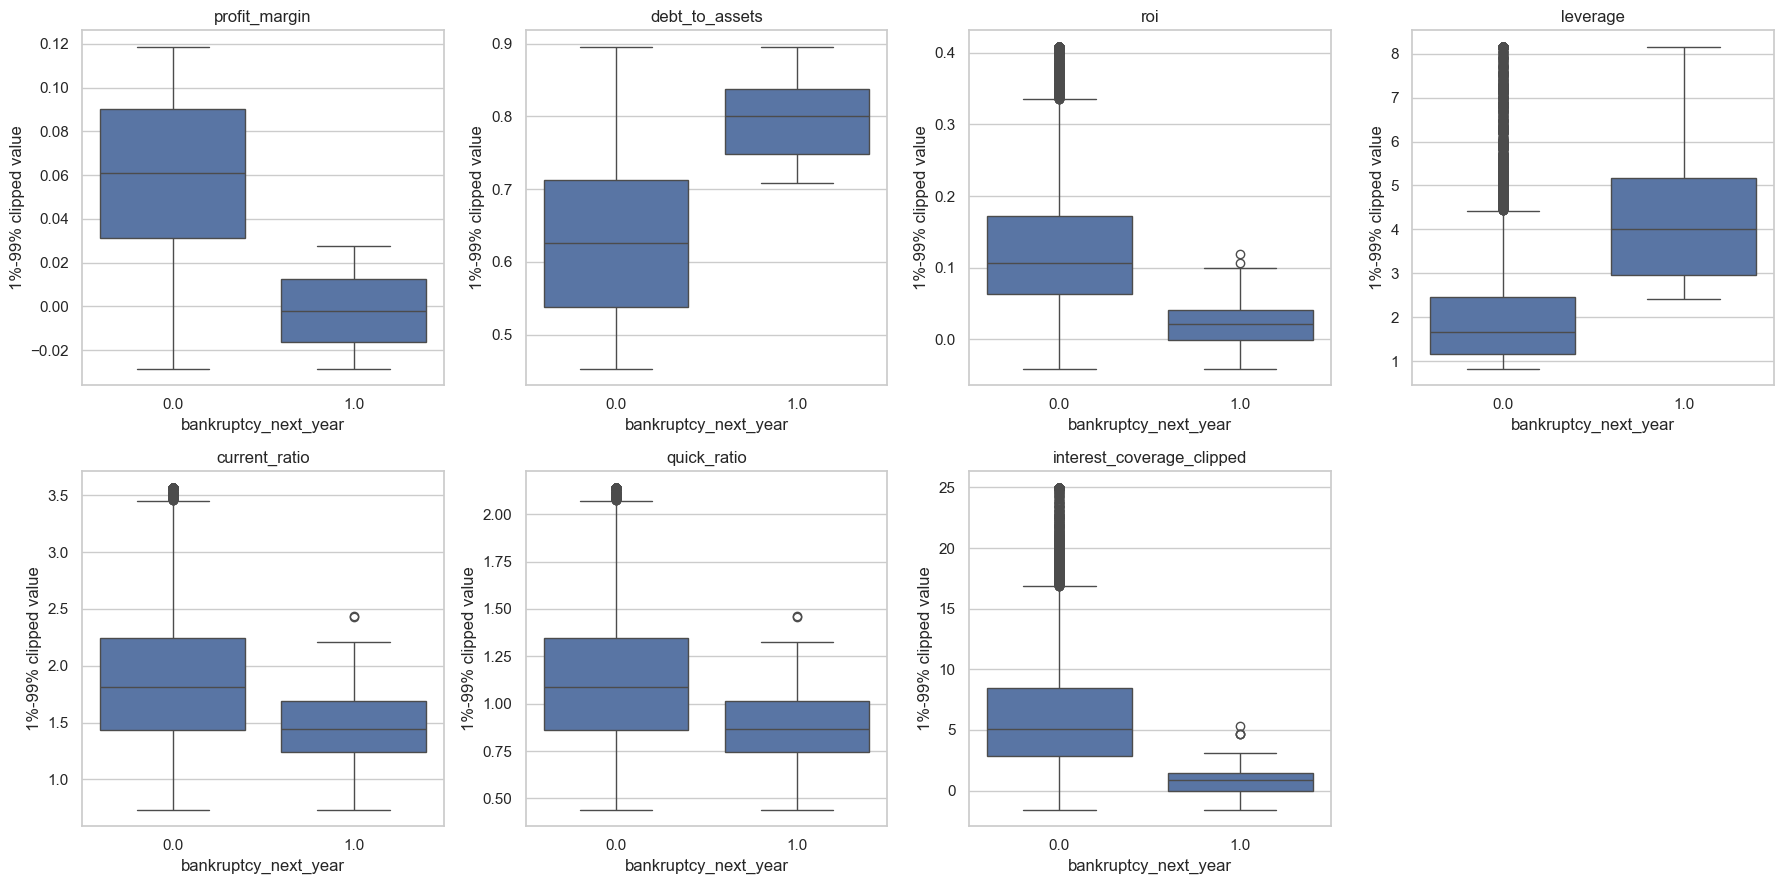

In [21]:
plot_features = [
    "profit_margin",
    "debt_to_assets",
    "roi",
    "leverage",
    "current_ratio",
    "quick_ratio",
    "interest_coverage_clipped",
]

risk_signal_summary = (
    train_model_df.groupby("bankruptcy_next_year")[plot_features]
    .median()
    .T
    .rename(columns={0: "healthy_median", 1: "bankruptcy_median"})
)
risk_signal_summary["bankruptcy_minus_healthy"] = (
    risk_signal_summary["bankruptcy_median"] - risk_signal_summary["healthy_median"]
)

print("Median risk-signal comparison:")
display(risk_signal_summary.sort_values("bankruptcy_minus_healthy"))

clipped_plot_df = train_model_df[["bankruptcy_next_year"] + plot_features].copy()
for feature in plot_features:
    clipped_plot_df[feature] = clipped_plot_df[feature].clip(
        clipped_plot_df[feature].quantile(0.01),
        clipped_plot_df[feature].quantile(0.99),
    )

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    sns.boxplot(data=clipped_plot_df, x="bankruptcy_next_year", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("bankruptcy_next_year")
    ax.set_ylabel("1%-99% clipped value")

for ax in axes[len(plot_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../images/engineered_risk_signals.png", bbox_inches="tight", dpi=150)
plt.show()

## 4. Candidate Feature Pool

With all features built, we define the full candidate pool. Company identifiers and fiscal year 
are excluded (they're not signals). The target variables from other challenges are dropped to 
avoid any cross-contamination.

The `must_keep_features` list is used for a narrow reason: some variables are central to the bankruptcy story even when a purely statistical ranking might move them slightly up or down across folds.

- **Core profitability and leverage**: `profit_margin`, `debt_to_assets`, `roi`, `current_ratio`, `interest_coverage_clipped`, and `altman_z_proxy` capture the main balance-sheet and earnings signals linked to distress
- **Direct distress flags**: `is_losing_money`, `weak_interest_cover_flag`, `thin_margin`, `thin_margin_high_debt`, and `distress_signal_count` summarize combinations that were consistently risky in the EDA
- **Deterioration over time**: `profit_margin_change`, `debt_to_assets_change`, `altman_z_proxy_change`, `profit_margin_decline_2y_flag`, `debt_build_up_2y_flag`, and `entering_distress` keep the time-dynamics that matter for one-year-ahead failure prediction
- **Relative and persistent weakness**: `profit_margin_vs_sector_year`, `debt_to_assets_vs_sector_year`, `loss_count_3y`, and `weak_interest_cover_count_3y` preserve sector context and repeated stress, which are financially meaningful even if their fold ranking moves

These features are kept because they represent the main financial signals used throughout the notebook.


In [22]:
FEATURE_SELECTION_TRAIN_YEARS = [2018, 2019]
FEATURE_SELECTION_VAL_YEAR = 2020
HOLDOUT_TRAIN_YEARS = [2018, 2019, 2020]
HOLDOUT_VAL_YEAR = 2021
TEST_YEARS = [2022, 2023]

target_col = "bankruptcy_next_year"
drop_cols = [
    "company_id",
    "fiscal_year",
    "bankruptcy_next_year",
]

candidate_features = [col for col in train_model_df.columns if col not in drop_cols]
must_keep_features = [
    "profit_margin",
    "debt_to_assets",
    "roi",
    "current_ratio",
    "interest_coverage_clipped",
    "altman_z_proxy",
    "is_losing_money",
    "weak_interest_cover_flag",
    "thin_margin",
    "thin_margin_high_debt",
    "distress_signal_count",
    "profit_margin_change",
    "debt_to_assets_change",
    "altman_z_proxy_change",
    "profit_margin_decline_2y_flag",
    "debt_build_up_2y_flag",
    "entering_distress",
    "profit_margin_vs_sector_year",
    "debt_to_assets_vs_sector_year",
    "loss_count_3y",
    "weak_interest_cover_count_3y",
]
must_keep_features = [col for col in must_keep_features if col in candidate_features]

selection_train_df = train_model_df[train_model_df["fiscal_year"].isin(FEATURE_SELECTION_TRAIN_YEARS)].copy()
selection_val_df = train_model_df[train_model_df["fiscal_year"] == FEATURE_SELECTION_VAL_YEAR].copy()

holdout_train_df = train_model_df[train_model_df["fiscal_year"].isin(HOLDOUT_TRAIN_YEARS)].copy()
holdout_val_df = train_model_df[train_model_df["fiscal_year"] == HOLDOUT_VAL_YEAR].copy()

split_summary_df = pd.DataFrame([
    {
        "split": "feature_selection",
        "train_years": ", ".join(map(str, FEATURE_SELECTION_TRAIN_YEARS)),
        "validation_year": FEATURE_SELECTION_VAL_YEAR,
        "train_rows": len(selection_train_df),
        "validation_rows": len(selection_val_df),
        "candidate_feature_count": len(candidate_features),
        "must_keep_count": len(must_keep_features),
    },
    {
        "split": "holdout_validation",
        "train_years": ", ".join(map(str, HOLDOUT_TRAIN_YEARS)),
        "validation_year": HOLDOUT_VAL_YEAR,
        "train_rows": len(holdout_train_df),
        "validation_rows": len(holdout_val_df),
        "candidate_feature_count": len(candidate_features),
        "must_keep_count": len(must_keep_features),
    },
])
display(split_summary_df)
display(pd.DataFrame({"must_keep_feature": must_keep_features}))


,split,train_years,validation_year,train_rows,validation_rows,candidate_feature_count,must_keep_count
0,feature_selection,"2018, 2019",2020,5940,2956,217,21
1,holdout_validation,"2018, 2019, 2020",2021,8896,2932,217,21


,must_keep_feature
0,profit_margin
1,debt_to_assets
2,roi
3,current_ratio
4,interest_coverage_clipped
5,altman_z_proxy
6,is_losing_money
7,weak_interest_cover_flag
8,thin_margin
9,thin_margin_high_debt


## 5. Feature Selection (Validated on 2020)

Standard cross-validation doesn't work here because randomly mixing years would let future data 
inform past predictions. The feature ranking and pruning steps are fit only on training years, then evaluated on 2020:

1. Drop pairs of numeric features with >95% Pearson correlation using only 2018-2019 training rows (redundancy reduction)
2. Rank remaining features using two temporal training windows: 2018 only, then 2018-2019
3. Average the fold rankings to produce a stable importance rank
4. Sweep different top-k feature counts and evaluate each on the 2020 validation year
5. Always keep the economic core features regardless of rank

The 2021 year stays completely untouched until the main model comparison step.

In [23]:
def prepare_raw_categorical_frame(df, categorical_cols):
    out = df.copy()
    for col in categorical_cols:
        out[col] = out[col].astype("string").fillna("Missing").astype(str)
    return out


def optimize_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        y_prob = np.asarray(y_prob)
        _, _, pr_thresholds = precision_recall_curve(y_true, y_prob)
        thresholds = np.unique(np.r_[
            0.0,
            1.0,
            y_prob,
            pr_thresholds,
            np.quantile(y_prob, np.linspace(0, 1, 501)),
            np.linspace(0.0001, 0.9999, 500),
        ])
        thresholds = thresholds[(thresholds >= 0) & (thresholds <= 1)]

    rows = []
    for threshold in thresholds:
        preds = (y_prob >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, preds),
            "f1": f1_score(y_true, preds, zero_division=0),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "predicted_positives": int(preds.sum()),
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(
        ["f1", "precision", "recall", "accuracy"],
        ascending=[False, False, False, False],
    ).iloc[0]
    return threshold_df, best_row


def compute_classifier_metrics(y_true, y_prob, threshold):
    preds = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1": f1_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "predicted_positives": int(preds.sum()),
    }


def prune_correlated_features(df, features, must_keep_features, corr_threshold=0.95):
    numeric_cols = df[features].select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in features if col not in numeric_cols]

    if not numeric_cols:
        return list(features), pd.DataFrame(columns=["dropped_feature", "kept_feature", "abs_correlation"])

    corr_matrix = df[numeric_cols].astype(float).corr().abs()
    ordered_numeric = list(dict.fromkeys(
        [col for col in must_keep_features if col in numeric_cols] +
        [col for col in numeric_cols if col not in must_keep_features]
    ))

    kept_numeric = []
    dropped_rows = []

    for col in ordered_numeric:
        if not kept_numeric:
            kept_numeric.append(col)
            continue

        high_corr = corr_matrix.loc[col, kept_numeric].dropna()
        high_corr = high_corr[high_corr >= corr_threshold]

        if not high_corr.empty and col not in must_keep_features:
            kept_feature = high_corr.sort_values(ascending=False).index[0]
            dropped_rows.append({
                "dropped_feature": col,
                "kept_feature": kept_feature,
                "abs_correlation": float(high_corr.max()),
            })
            continue

        kept_numeric.append(col)

    pruned_features = list(dict.fromkeys(
        [col for col in features if col in kept_numeric] +
        [col for col in categorical_cols]
    ))
    dropped_df = pd.DataFrame(dropped_rows)
    if not dropped_df.empty:
        dropped_df = dropped_df.sort_values(["abs_correlation", "dropped_feature"], ascending=[False, True]).reset_index(drop=True)
    return pruned_features, dropped_df


def rank_features_with_catboost(train_df, feature_list, target_col):
    fold_categorical_cols = train_df[feature_list].select_dtypes(exclude=["number", "bool"]).columns.tolist()
    cb_train = prepare_raw_categorical_frame(train_df[feature_list], fold_categorical_cols)
    cat_idx = [cb_train.columns.get_loc(col) for col in fold_categorical_cols]

    ranker = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    ranker.fit(cb_train, train_df[target_col], cat_features=cat_idx)

    ranking_df = pd.DataFrame({
        "feature": feature_list,
        "importance": ranker.get_feature_importance(),
    }).sort_values(["importance", "feature"], ascending=[False, True]).reset_index(drop=True)
    ranking_df["rank"] = np.arange(1, len(ranking_df) + 1)
    return ranking_df

### 5.1 Running the Selection Pipeline

We now apply the correlation pruning and CatBoost ranking step. The result is a stable importance table 
built from two temporal training windows rather than from a single year.

In [24]:
pruned_candidate_features, correlation_drop_df = prune_correlated_features(
    selection_train_df,
    candidate_features,
    must_keep_features,
    corr_threshold=0.95,
)

feature_selection_summary_df = pd.DataFrame([{
    "candidate_feature_count_before_pruning": len(candidate_features),
    "candidate_feature_count_after_pruning": len(pruned_candidate_features),
    "correlation_pruned_feature_count": len(correlation_drop_df),
}])
display(feature_selection_summary_df)
if not correlation_drop_df.empty:
    display(correlation_drop_df.head(15).round(4))

feature_selection_folds = [
    {"fold_name": "2018_to_2019", "train_years": [2018]},
    {"fold_name": "2018_2019_to_2020", "train_years": [2018, 2019]},
]

fold_rank_tables = []
for fold in feature_selection_folds:
    fold_train_df = train_model_df[train_model_df["fiscal_year"].isin(fold["train_years"])]
    fold_ranking_df = rank_features_with_catboost(fold_train_df, pruned_candidate_features, target_col)

    fold_rank_tables.append(
        fold_ranking_df.rename(columns={
            "importance": f"{fold['fold_name']}_importance",
            "rank": f"{fold['fold_name']}_rank",
        })
    )

stable_feature_ranking_df = fold_rank_tables[0]
for fold_table in fold_rank_tables[1:]:
    stable_feature_ranking_df = stable_feature_ranking_df.merge(fold_table, on="feature", how="inner")

rank_cols = [col for col in stable_feature_ranking_df.columns if col.endswith("_rank")]
importance_cols = [col for col in stable_feature_ranking_df.columns if col.endswith("_importance")]

stable_feature_ranking_df["top20_fold_hits"] = (stable_feature_ranking_df[rank_cols] <= 20).sum(axis=1)
stable_feature_ranking_df["median_rank"] = stable_feature_ranking_df[rank_cols].median(axis=1)
stable_feature_ranking_df["mean_rank"] = stable_feature_ranking_df[rank_cols].mean(axis=1)
stable_feature_ranking_df["mean_importance"] = stable_feature_ranking_df[importance_cols].mean(axis=1)
stable_feature_ranking_df["must_keep"] = stable_feature_ranking_df["feature"].isin(must_keep_features).astype(int)

stable_feature_ranking_df = stable_feature_ranking_df.sort_values(
    ["top20_fold_hits", "median_rank", "mean_rank", "mean_importance"],
    ascending=[False, True, True, False],
).reset_index(drop=True)

selection_categorical_cols = selection_train_df[pruned_candidate_features].select_dtypes(exclude=["number", "bool"]).columns.tolist()
display(stable_feature_ranking_df.head(30).round(4))

,candidate_feature_count_before_pruning,candidate_feature_count_after_pruning,correlation_pruned_feature_count
0,217,170,47


,dropped_feature,kept_feature,abs_correlation
0,altman_z_proxy_lag_missing,profit_margin_lag_missing,1.0
1,consecutive_loss_years,loss_count_3y,1.0
2,current_ratio_lag_missing,profit_margin_lag_missing,1.0
3,debt_to_assets_lag_missing,profit_margin_lag_missing,1.0
4,ic_trend,interest_coverage_clipped_change,1.0
5,ic_vs_sector,interest_coverage_clipped_vs_sector_year,1.0
6,interest_coverage_proxy,interest_coverage_clipped,1.0
7,leverage_history_imputed_flag,roe_history_imputed_flag,1.0
8,leverage_missing,roe_missing,1.0
9,leverage_peer_imputed_flag,roe_peer_imputed_flag,1.0


,feature,2018_to_2019_importance,2018_to_2019_rank,2018_2019_to_2020_importance,2018_2019_to_2020_rank,top20_fold_hits,median_rank,mean_rank,mean_importance,must_keep
0,fin_expense_per_asset,4.8425,2,2.5327,6,2,4.0,4.0,3.6876,0
1,profit_margin_vs_sector_year,2.6063,8,2.7271,4,2,6.0,6.0,2.6667,1
2,thin_margin_high_debt,2.3566,12,7.2126,1,2,6.5,6.5,4.7846,1
3,debt_to_assets_vs_sector_year,4.2301,4,1.9724,10,2,7.0,7.0,3.1012,1
4,size_x_leverage,2.1277,15,2.7777,3,2,9.0,9.0,2.4527,0
5,years_in_business,3.2137,5,1.7467,17,2,11.0,11.0,2.4802,0
6,roi_vs_sector_year,3.1238,7,1.7545,15,2,11.0,11.0,2.4391,0
7,leverage_capped,2.2683,14,2.1890,8,2,11.0,11.0,2.2287,0
8,profit_margin,1.8971,17,2.5117,7,2,12.0,12.0,2.2044,1
9,debt_gap,2.4682,9,1.6612,20,2,14.5,14.5,2.0647,0


### 5.2 Sweeping Feature Counts

With the ranked feature list in hand, we test configurations from top-10 to top-60 features on the 2020 
validation year. We pick the smallest count whose PR-AUC is within a small tolerance of the best, 
fewer features generally generalize better when performance is otherwise similar.

In [25]:
topk_candidates = sorted(set([10, 15, 20, 25, 30, 40, 50, 60]))
topk_candidates = [k for k in topk_candidates if 1 <= k <= len(pruned_candidate_features)]

feature_sweep_rows = []
feature_sweep_artifacts = {}

for top_k in topk_candidates:
    selected_feature_list = list(dict.fromkeys(
        stable_feature_ranking_df["feature"].head(top_k).tolist() + must_keep_features
    ))

    cb_train_k = prepare_raw_categorical_frame(selection_train_df[selected_feature_list], [c for c in selected_feature_list if c in selection_categorical_cols])
    cb_val_k = prepare_raw_categorical_frame(selection_val_df[selected_feature_list], [c for c in selected_feature_list if c in selection_categorical_cols])
    cat_idx_k = [cb_train_k.columns.get_loc(col) for col in cb_train_k.columns if col in selection_categorical_cols]

    model_k = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    model_k.fit(cb_train_k, selection_train_df[target_col], cat_features=cat_idx_k)
    val_prob_k = model_k.predict_proba(cb_val_k)[:, 1]

    threshold_table_k, best_threshold_row_k = optimize_threshold(selection_val_df[target_col], val_prob_k)
    metrics_k = compute_classifier_metrics(
        selection_val_df[target_col],
        val_prob_k,
        float(best_threshold_row_k["threshold"]),
    )

    row = {
        "top_k": top_k,
        "selected_feature_count": len(selected_feature_list),
        "threshold": float(best_threshold_row_k["threshold"]),
    }
    row.update(metrics_k)
    feature_sweep_rows.append(row)

    feature_sweep_artifacts[top_k] = {
        "features": selected_feature_list,
    }

FEATURE_SELECTION_TIE_TOLERANCE = 0.005

feature_sweep_df = pd.DataFrame(feature_sweep_rows).sort_values(
    ["pr_auc", "roc_auc", "f1"],
    ascending=[False, False, False],
).reset_index(drop=True)

best_prauc = float(feature_sweep_df.iloc[0]["pr_auc"])
compact_candidates = feature_sweep_df[
    feature_sweep_df["pr_auc"] >= (best_prauc - FEATURE_SELECTION_TIE_TOLERANCE)
].copy()
compact_candidates = compact_candidates.sort_values(
    ["top_k", "roc_auc", "f1"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(feature_sweep_df.round(4))
display(compact_candidates.round(4))

best_top_k = int(compact_candidates.iloc[0]["top_k"])
final_features = feature_sweep_artifacts[best_top_k]["features"]

final_feature_summary_df = pd.DataFrame([{
    "selected_top_k": best_top_k,
    "final_feature_count": len(final_features),
}])
display(final_feature_summary_df)


,top_k,selected_feature_count,threshold,accuracy,f1,precision,recall,roc_auc,pr_auc,false_positives,false_negatives,predicted_positives
0,30,43,0.1063,0.9770,0.1500,0.0938,0.3750,0.9388,0.0713,58,10,64
1,60,69,0.2125,0.9838,0.1724,0.1190,0.3125,0.9427,0.0700,37,11,42
2,20,37,0.2025,0.9844,0.1481,0.1053,0.2500,0.9257,0.0625,34,12,38
3,50,61,0.2325,0.9861,0.1277,0.0968,0.1875,0.9270,0.0481,28,13,31
4,10,27,0.1256,0.9689,0.0980,0.0581,0.3125,0.9195,0.0436,81,11,86
5,15,32,0.1424,0.9787,0.0870,0.0566,0.1875,0.9263,0.0431,50,13,53
6,40,52,0.2741,0.9888,0.1081,0.0952,0.1250,0.9196,0.0421,19,14,21
7,25,40,0.0332,0.9337,0.0926,0.0500,0.6250,0.9284,0.0412,190,6,200


,top_k,selected_feature_count,threshold,accuracy,f1,precision,recall,roc_auc,pr_auc,false_positives,false_negatives,predicted_positives
0,30,43,0.1063,0.9770,0.1500,0.0938,0.3750,0.9388,0.0713,58,10,64
1,60,69,0.2125,0.9838,0.1724,0.1190,0.3125,0.9427,0.0700,37,11,42


,selected_top_k,final_feature_count
0,30,43


## 6. Model Comparison (Validated on 2021)

With the feature set locked from the previous step, we now train five candidate models on 2018–2020 and evaluate them on 2021. 
This is the main model selection step.

**Models compared:**
- **Regularized Logistic Regression**: linear baseline with robust scaling and class weights
- **Random Forest**: bagged tree ensemble baseline with nonlinear interactions
- **LightGBM**: gradient boosting optimized for speed and sparse features
- **XGBoost**: strong gradient boosting baseline
- **CatBoost**: strong boosting model for tabular data, included as a robust nonlinear benchmark

All models receive imbalance-aware settings. Thresholds are tuned per model to maximize F1 on the 2021 validation year.


In [26]:
def build_preprocessor(X_train, model_name):
    categorical_cols = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if model_name == "RegularizedLogistic":
        numeric_steps.append(("scaler", RobustScaler(quantile_range=(10, 90))))

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_cols),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", ohe),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )
    return preprocessor


def build_model(model_name, pos_weight):
    model_builders = {
        "RegularizedLogistic": lambda: LogisticRegression(
            max_iter=4000,
            class_weight="balanced",
            C=0.5,
            random_state=RANDOM_STATE,
        ),
        "RandomForest": lambda: RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "LightGBM": lambda: LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.01,
            num_leaves=15,
            min_child_samples=1,
            scale_pos_weight=pos_weight,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=0.5,
            reg_lambda=2.0,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1,
        ),
        "XGBoost": lambda: XGBClassifier(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=3,
            min_child_weight=1,
            scale_pos_weight=pos_weight,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=0.5,
            reg_lambda=2.0,
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            verbosity=0,
        ),
        "CatBoost": lambda: CatBoostClassifier(
            iterations=600,
            learning_rate=0.05,
            depth=5,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            verbose=0,
            random_seed=RANDOM_STATE,
        ),
    }
    return model_builders[model_name]()


### 6.1 Training the Candidate Models

Each model is trained on the 2018–2020 period and scored on the 2021 holdout. 
The threshold search runs across the full precision-recall curve for each model.


In [27]:
X_train_holdout = holdout_train_df[final_features].copy()
y_train_holdout = holdout_train_df[target_col].copy()
X_val_holdout = holdout_val_df[final_features].copy()
y_val_holdout = holdout_val_df[target_col].copy()

pos_weight = (y_train_holdout == 0).sum() / max((y_train_holdout == 1).sum(), 1)

model_names = [
    "RegularizedLogistic",
    "RandomForest",
    "LightGBM",
    "XGBoost",
    "CatBoost",
]

model_results = []
model_runs = {}

for model_name in model_names:
    model = build_model(model_name, pos_weight=pos_weight)
    preprocessor = build_preprocessor(X_train_holdout, model_name=model_name)
    pipeline = Pipeline(
        steps=[
            ("preprocess", clone(preprocessor)),
            ("model", model),
        ]
    )
    pipeline.fit(X_train_holdout, y_train_holdout)
    val_prob = pipeline.predict_proba(X_val_holdout)[:, 1]

    threshold_table, best_threshold_row = optimize_threshold(y_val_holdout, val_prob)
    selected_threshold = float(best_threshold_row["threshold"])
    metrics = compute_classifier_metrics(y_val_holdout, val_prob, selected_threshold)

    model_results.append({"model": model_name, "threshold": selected_threshold, **metrics})
    model_runs[model_name] = {
        "pipeline": pipeline,
        "val_prob": val_prob,
        "threshold": selected_threshold,
        "threshold_table": threshold_table,
        "metrics": metrics,
    }

model_results_df = pd.DataFrame(model_results).sort_values(
    ["f1", "precision", "recall", "roc_auc", "pr_auc"],
    ascending=[False, False, False, False, False],
).reset_index(drop=True)

display(model_results_df.round(4))


,model,threshold,accuracy,f1,precision,recall,roc_auc,pr_auc,false_positives,false_negatives,predicted_positives
0,RegularizedLogistic,0.9278,0.9887,0.2326,0.2273,0.2381,0.9444,0.1096,17,16,22
1,CatBoost,0.6933,0.9922,0.1481,0.3333,0.0952,0.9231,0.0757,4,19,6
2,RandomForest,0.1624,0.9840,0.1455,0.1176,0.1905,0.9342,0.0708,30,17,34
3,LightGBM,0.0601,0.9587,0.1295,0.0763,0.4286,0.9309,0.0645,109,12,118
4,XGBoost,0.4128,0.9482,0.1264,0.0719,0.5238,0.9338,0.0655,142,10,153


### 6.2 Comparison Results

With all models trained, we compare them on 2021. The final model is selected by **F1**, 
but **PR-AUC** and **ROC-AUC** are reported alongside because the holdout year contains only a small number of bankruptcies.
That means one or two firms can move F1 noticeably, so the ranking metrics help us judge whether a small gap is meaningful.


,model,threshold,f1,precision,recall,pr_auc,roc_auc
0,RegularizedLogistic,0.9278,0.2326,0.2273,0.2381,0.1096,0.9444


              precision    recall  f1-score   support

         0.0     0.9945    0.9942    0.9943      2911
         1.0     0.2273    0.2381    0.2326        21

    accuracy                         0.9887      2932
   macro avg     0.6109    0.6161    0.6134      2932
weighted avg     0.9890    0.9887    0.9889      2932



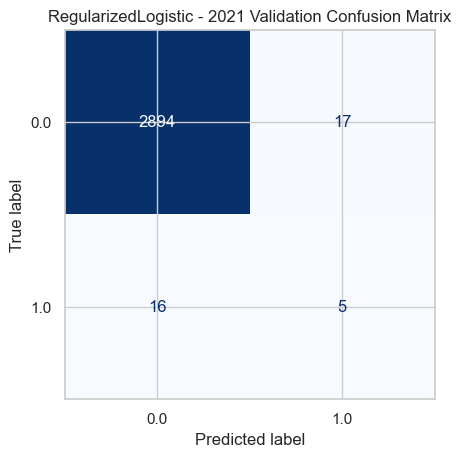

In [28]:
best_model_name = model_results_df.iloc[0]["model"]
best_run = model_runs[best_model_name]
best_pipeline = best_run["pipeline"]
best_f1_threshold = best_run["threshold"]
best_val_pred = (best_run["val_prob"] >= best_f1_threshold).astype(int)

best_model_summary = pd.DataFrame([
    {
        "model": best_model_name,
        "threshold": best_f1_threshold,
        "f1": best_run["metrics"]["f1"],
        "precision": best_run["metrics"]["precision"],
        "recall": best_run["metrics"]["recall"],
        "pr_auc": best_run["metrics"]["pr_auc"],
        "roc_auc": best_run["metrics"]["roc_auc"],
    }
])
display(best_model_summary.round(4))
print(classification_report(y_val_holdout, best_val_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_val_holdout,
    best_val_pred,
    cmap="Blues",
    colorbar=False,
)
plt.title(f"{best_model_name} - 2021 Validation Confusion Matrix")
plt.show()


### 6.3 Precision-Recall Curves and Metric Choice

The labeled data is highly imbalanced, with bankruptcy representing only a very small share of all firms. 
In this setting, `F1` can move noticeably when only a few companies cross the decision threshold.

For that reason, we still select the final model by **F1** on 2021, while using **PR-AUC** to judge ranking quality. 
The precision-recall curves below show how much precision each model can maintain as recall increases.


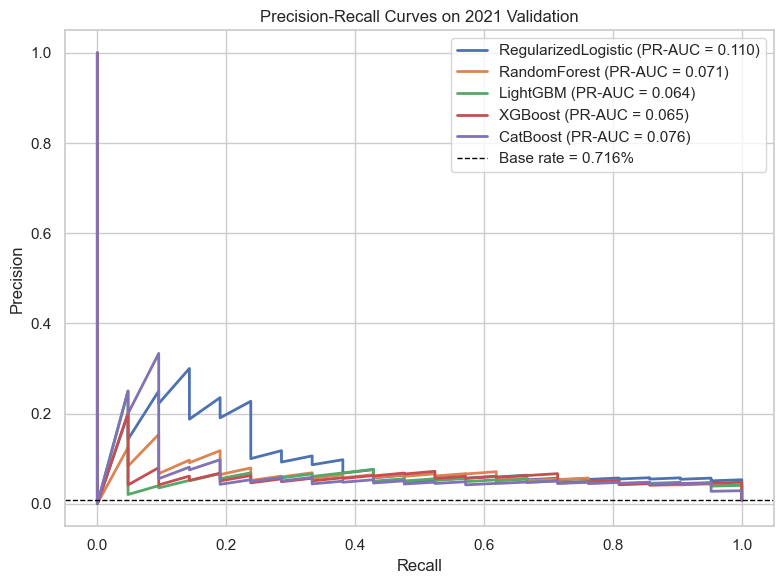

,model,pr_auc
0,RegularizedLogistic,0.1096
4,CatBoost,0.0757
1,RandomForest,0.0708
3,XGBoost,0.0655
2,LightGBM,0.0645


In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

pr_curve_rows = []
for model_name, run in model_runs.items():
    precision, recall, _ = precision_recall_curve(y_val_holdout, run["val_prob"])
    pr_auc = average_precision_score(y_val_holdout, run["val_prob"])
    ax.plot(recall, precision, linewidth=2, label=f"{model_name} (PR-AUC = {pr_auc:.3f})")
    pr_curve_rows.append({"model": model_name, "pr_auc": pr_auc})

baseline_rate = y_val_holdout.mean()
ax.axhline(baseline_rate, color="black", linestyle="--", linewidth=1, label=f"Base rate = {baseline_rate:.3%}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves on 2021 Validation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(pd.DataFrame(pr_curve_rows).sort_values("pr_auc", ascending=False).round(4))


### 6.4 Ranking Performance (Top-K Analysis)

F1-score measures performance at a single threshold. But for credit risk, a natural question is: 
if we flag the top K companies as risky, how many real bankruptcies do we catch? This matters 
when the number of companies a team can review is fixed by operational capacity.


In [30]:
def summarize_topk_ranking(y_true, y_prob, topk_values=(5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 300)):
    rank_df = (
        pd.DataFrame({"actual": y_true, "probability": y_prob}, index=y_true.index)
        .sort_values("probability", ascending=False)
        .reset_index(drop=True)
    )
    rows = []
    total_positives = int(y_true.sum())
    for top_k in topk_values:
        top_slice = rank_df.head(top_k)
        tp = int(top_slice["actual"].sum())
        fp = int(top_k - tp)
        fn = int(total_positives - tp)
        precision = tp / top_k if top_k else 0
        recall = tp / total_positives if total_positives else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )
        rows.append({
            "top_k_predicted_bankrupt": top_k,
            "true_bankruptcies_found": tp,
            "false_positives": fp,
            "false_negatives": fn,
            "precision": precision,
            "recall": recall,
            "f1_if_threshold_at_top_k": f1,
        })
    return pd.DataFrame(rows)


topk_diagnostics = {}
diagnostic_rows = []
for model_name, run in model_runs.items():
    topk_df = summarize_topk_ranking(y_val_holdout, run["val_prob"])
    best_topk_row = topk_df.sort_values(
        ["f1_if_threshold_at_top_k", "precision", "recall"],
        ascending=[False, False, False],
    ).iloc[0]
    topk_diagnostics[model_name] = topk_df
    diagnostic_rows.append({
        "model": model_name,
        "best_top_k": int(best_topk_row["top_k_predicted_bankrupt"]),
        "true_bankruptcies_found": int(best_topk_row["true_bankruptcies_found"]),
        "false_positives": int(best_topk_row["false_positives"]),
        "false_negatives": int(best_topk_row["false_negatives"]),
        "best_topk_f1": float(best_topk_row["f1_if_threshold_at_top_k"]),
    })

ranking_diagnostic_df = pd.DataFrame(diagnostic_rows).sort_values(
    ["best_topk_f1", "true_bankruptcies_found", "false_positives"],
    ascending=[False, False, True],
)
display(ranking_diagnostic_df.round(4))

display(topk_diagnostics[best_model_name].round(4))

,model,best_top_k,true_bankruptcies_found,false_positives,false_negatives,best_topk_f1
0,RegularizedLogistic,25,5,20,16,0.2174
1,RandomForest,40,4,36,17,0.1311
4,CatBoost,10,2,8,19,0.1290
3,XGBoost,150,10,140,11,0.1170
2,LightGBM,150,9,141,12,0.1053


,top_k_predicted_bankrupt,true_bankruptcies_found,false_positives,false_negatives,precision,recall,f1_if_threshold_at_top_k
0,5,1,4,20,0.2000,0.0476,0.0769
1,10,3,7,18,0.3000,0.1429,0.1935
2,15,3,12,18,0.2000,0.1429,0.1667
3,20,4,16,17,0.2000,0.1905,0.1951
4,25,5,20,16,0.2000,0.2381,0.2174
5,30,5,25,16,0.1667,0.2381,0.1961
6,40,5,35,16,0.1250,0.2381,0.1639
7,50,5,45,16,0.1000,0.2381,0.1408
8,75,7,68,14,0.0933,0.3333,0.1458
9,100,8,92,13,0.0800,0.3810,0.1322


## 7. Business Threshold Tuning

The best-F1 threshold treats precision and recall symmetrically. But missing a bankruptcy is far 
more costly than flagging a healthy company. A missed bankruptcy means no intervention, while a 
false positive just triggers a review.

We model this explicitly:
- **False negative cost = 25** (missing a bankrupt company is very expensive)
- **False positive cost = 1** (flagging a healthy company is manageable)

This produces a more conservative threshold that deliberately sacrifices precision for recall. 
Both operating points are shown in the confusion matrices below.


In [31]:
FALSE_NEGATIVE_COST = 25
FALSE_POSITIVE_COST = 1

best_threshold_table = best_run["threshold_table"].copy()
best_threshold_table["false_positives"] = None
best_threshold_table["false_negatives"] = None
best_threshold_table["business_cost"] = None

for idx, row in best_threshold_table.iterrows():
    threshold = float(row["threshold"])
    preds = (best_run["val_prob"] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_holdout, preds, labels=[0, 1]).ravel()
    best_threshold_table.loc[idx, "false_positives"] = int(fp)
    best_threshold_table.loc[idx, "false_negatives"] = int(fn)
    best_threshold_table.loc[idx, "business_cost"] = int(FALSE_NEGATIVE_COST * fn + FALSE_POSITIVE_COST * fp)

best_threshold_table["false_positives"] = best_threshold_table["false_positives"].astype(int)
best_threshold_table["false_negatives"] = best_threshold_table["false_negatives"].astype(int)
best_threshold_table["business_cost"] = best_threshold_table["business_cost"].astype(int)

print("Best threshold analysis:")
display(
    best_threshold_table.sort_values(
        ["f1", "precision", "recall"], ascending=[False, False, False]
    ).head(10).round(4)
)
print("Best threshold analysis (by business cost):")
display(
    best_threshold_table.sort_values(
        ["business_cost", "false_negatives", "false_positives", "f1"],
        ascending=[True, True, True, False],
    ).head(10).round(4)
)

Best threshold analysis:


,threshold,accuracy,f1,precision,recall,predicted_positives,false_positives,false_negatives,business_cost
3870,0.9278,0.9887,0.2326,0.2273,0.2381,22,17,16,417
3871,0.9281,0.9887,0.2326,0.2273,0.2381,22,17,16,417
3869,0.9278,0.9884,0.2273,0.2174,0.2381,23,18,16,418
3866,0.9255,0.9881,0.2222,0.2083,0.2381,24,19,16,419
3867,0.9258,0.9881,0.2222,0.2083,0.2381,24,19,16,419
3868,0.9264,0.9881,0.2222,0.2083,0.2381,24,19,16,419
3862,0.9198,0.9877,0.2174,0.2000,0.2381,25,20,16,420
3863,0.9218,0.9877,0.2174,0.2000,0.2381,25,20,16,420
3864,0.9238,0.9877,0.2174,0.2000,0.2381,25,20,16,420
3865,0.9244,0.9877,0.2174,0.2000,0.2381,25,20,16,420


Best threshold analysis (by business cost):


,threshold,accuracy,f1,precision,recall,predicted_positives,false_positives,false_negatives,business_cost
3301,0.5631,0.8864,0.1072,0.0568,0.9524,352,332,1,357
3302,0.5638,0.8864,0.1072,0.0568,0.9524,352,332,1,357
3303,0.5651,0.8864,0.1072,0.0568,0.9524,352,332,1,357
3304,0.5659,0.8864,0.1072,0.0568,0.9524,352,332,1,357
3299,0.5611,0.8861,0.1070,0.0567,0.9524,353,333,1,358
3300,0.5630,0.8861,0.1070,0.0567,0.9524,353,333,1,358
3297,0.5591,0.8857,0.1067,0.0565,0.9524,354,334,1,359
3298,0.5600,0.8857,0.1067,0.0565,0.9524,354,334,1,359
3293,0.5531,0.8854,0.1064,0.0563,0.9524,355,335,1,360
3294,0.5551,0.8854,0.1064,0.0563,0.9524,355,335,1,360


### 7.1 False Negative Budget

A practical way to use the cost table: if the business says 'we can tolerate at most N missed 
bankruptcies', what's the optimal threshold that achieves that constraint at minimum total cost?

In [32]:
def summarize_fn_budget(threshold_df, allowed_false_negatives=(0, 1, 2, 3, 4, 5)):
    rows = []
    for fn_limit in allowed_false_negatives:
        candidates = threshold_df[threshold_df["false_negatives"] <= fn_limit].copy()
        if candidates.empty:
            continue

        selected = candidates.sort_values(
            ["business_cost", "f1", "accuracy", "false_positives"],
            ascending=[True, False, False, True],
        ).iloc[0]

        rows.append({
            "allowed_false_negatives": fn_limit,
            "threshold": float(selected["threshold"]),
            "accuracy": float(selected["accuracy"]),
            "f1": float(selected["f1"]),
            "precision": float(selected["precision"]),
            "recall": float(selected["recall"]),
            "false_negatives": int(selected["false_negatives"]),
            "false_positives": int(selected["false_positives"]),
            "business_cost": int(selected["business_cost"]),
        })
    return pd.DataFrame(rows)


fn_budget_summary = summarize_fn_budget(best_threshold_table)
print("False-negative budget scenarios for the selected model:")
display(fn_budget_summary.round(4))

business_threshold = None
if not fn_budget_summary.empty:
    business_choice = best_threshold_table.sort_values(
        ["business_cost", "false_negatives", "false_positives", "f1"],
        ascending=[True, True, True, False],
    )
    business_threshold = float(
        business_choice.iloc[0]["threshold"]
    )
    print("Recommended business threshold:", round(business_threshold, 4))

False-negative budget scenarios for the selected model:


,allowed_false_negatives,threshold,accuracy,f1,precision,recall,false_negatives,false_positives,business_cost
0,0,0.4649,0.8724,0.1010,0.0532,1.0000,0,374,374
1,1,0.5631,0.8864,0.1072,0.0568,0.9524,1,332,357
2,2,0.5631,0.8864,0.1072,0.0568,0.9524,1,332,357
3,3,0.5631,0.8864,0.1072,0.0568,0.9524,1,332,357
4,4,0.5631,0.8864,0.1072,0.0568,0.9524,1,332,357
5,5,0.5631,0.8864,0.1072,0.0568,0.9524,1,332,357


Recommended business threshold: 0.5631


### 7.2 Confusion Matrices: F1 vs. Business Threshold

The two matrices make the tradeoff concrete. Left uses the best-F1 threshold; right uses the 
business-cost threshold. The shift in false negatives vs. false positives is the main story here.

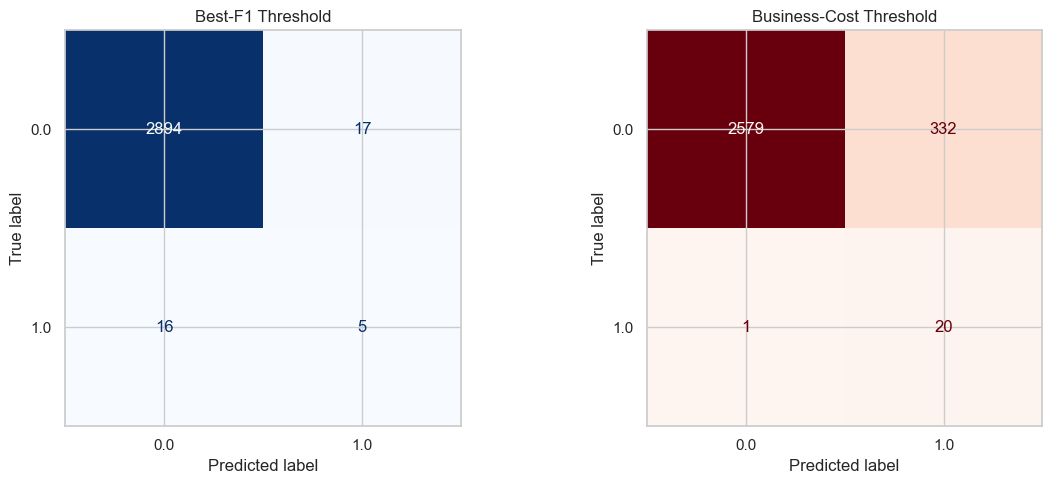

Validation threshold summary:


,threshold_label,threshold,accuracy,f1,precision,recall,predicted_positives,true_positives,false_positives,false_negatives,true_negatives
0,Best-F1,0.9278,0.9887,0.2326,0.2273,0.2381,22,5,17,16,2894
1,Business-Cost,0.5631,0.8864,0.1072,0.0568,0.9524,352,20,332,1,2579


In [33]:
y_val_actual = y_val_holdout
y_val_prob = best_run["val_prob"]
y_val_pred_f1 = (y_val_prob >= best_f1_threshold).astype(int)
active_business_threshold = business_threshold if business_threshold is not None else best_f1_threshold
y_val_pred_business = (y_val_prob >= active_business_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_actual,
    y_val_pred_f1,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Best-F1 Threshold")

ConfusionMatrixDisplay.from_predictions(
    y_val_actual,
    y_val_pred_business,
    cmap="Reds",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Business-Cost Threshold")

plt.tight_layout()
plt.savefig("../images/confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

def summarize_threshold_result(label, threshold, preds):
    metrics = compute_classifier_metrics(y_val_actual, y_val_prob, threshold)
    tn, fp, fn, tp = confusion_matrix(y_val_actual, preds).ravel()
    return {"threshold_label": label,"threshold": float(threshold),"accuracy": float(metrics["accuracy"]),"f1": float(metrics["f1"]),"precision": float(metrics["precision"]),"recall": float(metrics["recall"]),"predicted_positives": int(metrics["predicted_positives"]),"true_positives": int(tp),"false_positives": int(fp),"false_negatives": int(fn),"true_negatives": int(tn)}

validation_summary = pd.DataFrame([
    summarize_threshold_result("Best-F1", best_f1_threshold, y_val_pred_f1),
    summarize_threshold_result("Business-Cost", active_business_threshold, y_val_pred_business),
])

print("Validation threshold summary:")
display(validation_summary.round(4))

## 8. Final Model and Test Predictions

The test set covers 2022–2023, and we don't have labels for it, so no real test metric is available here. 
We refit the selected model on all labeled years (2018–2021) and generate predictions using both thresholds. 
The final submission file contains probabilities and binary predictions for each test company.

In [34]:
X_train_final = train_model_df[train_model_df["fiscal_year"].isin(HOLDOUT_TRAIN_YEARS + [HOLDOUT_VAL_YEAR])][final_features].copy()
y_train_final = train_model_df[train_model_df["fiscal_year"].isin(HOLDOUT_TRAIN_YEARS + [HOLDOUT_VAL_YEAR])][target_col].copy()
X_test_final = test_model_df[final_features].copy()

final_pos_weight = (y_train_final == 0).sum() / max((y_train_final == 1).sum(), 1)
final_model = build_model(best_model_name, pos_weight=final_pos_weight)
final_preprocessor = build_preprocessor(X_train_final, model_name=best_model_name)

final_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(final_preprocessor)),
        ("model", final_model),
    ]
)
final_pipeline.fit(X_train_final, y_train_final)
test_prob = final_pipeline.predict_proba(X_test_final)[:, 1]

prediction_output = test_model_df[["company_id", "fiscal_year"]].copy()
prediction_output["bankruptcy_probability"] = test_prob
prediction_output["prediction_f1_threshold"] = (test_prob >= best_f1_threshold).astype(int)
prediction_output["prediction_business_threshold"] = (
    (test_prob >= business_threshold).astype(int)
    if business_threshold is not None else
    (test_prob >= best_f1_threshold).astype(int)
)

output_path = Path("../outputs/test_predictions.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
prediction_output.to_csv(output_path, index=False)

display(prediction_output.head(10))


,company_id,fiscal_year,bankruptcy_probability,prediction_f1_threshold,prediction_business_threshold
4,COMP_00000,2022,2.859720e-10,0,0
5,COMP_00000,2023,4.540052e-08,0,0
10,COMP_00001,2022,3.549863e-04,0,0
11,COMP_00001,2023,5.793401e-05,0,0
16,COMP_00002,2022,4.682596e-05,0,0
17,COMP_00002,2023,7.106712e-01,0,1
21,COMP_00003,2022,1.103912e-03,0,0
22,COMP_00003,2023,9.656893e-01,1,1
27,COMP_00004,2022,2.042536e-04,0,0
32,COMP_00005,2022,3.695881e-06,0,0


## 9. Model Interpretation

We interpret the final model with SHAP so we can see which features push predictions toward `bankruptcy` and which push them toward `healthy`.

Important note: the explanations below are based on the **holdout pipeline trained on 2018–2020** and applied to **2021 validation predictions**. 
They do **not** use the final refit pipeline trained on 2018–2021 for test predictions, because the holdout pipeline is the honest model used for validation and error analysis.

- **Positive SHAP value** → pushes the score toward bankruptcy
- **Negative SHAP value** → pushes the score toward healthy
- **Global importance** shows which features matter most across the validation sample
- **Risk-case importance** shows which features are most common among the highest-risk companies


,feature,mean_abs_shap
21,num__debt_band_risky,1.106140
2,num__thin_margin_high_debt,1.072468
26,num__thin_margin,1.039186
11,num__current_ratio_vs_sector_year,0.966431
41,num__loss_count_3y,0.733857
42,num__weak_interest_cover_count_3y,0.733857
14,num__operating_margin_vs_sector_year,0.610167
13,num__fixed_asset_ratio,0.518630
19,num__short_debt_to_assets,0.489270
36,num__debt_to_assets_change,0.478805


,feature,mean_shap_on_high_risk_cases
2,num__thin_margin_high_debt,2.655715
26,num__thin_margin,2.060947
21,num__debt_band_risky,1.589621
11,num__current_ratio_vs_sector_year,1.588917
14,num__operating_margin_vs_sector_year,1.030012
34,num__distress_signal_count,0.927953
37,num__altman_z_proxy_change,0.826773
36,num__debt_to_assets_change,0.756814
33,num__weak_interest_cover_flag,0.699635
32,num__is_losing_money,0.699635


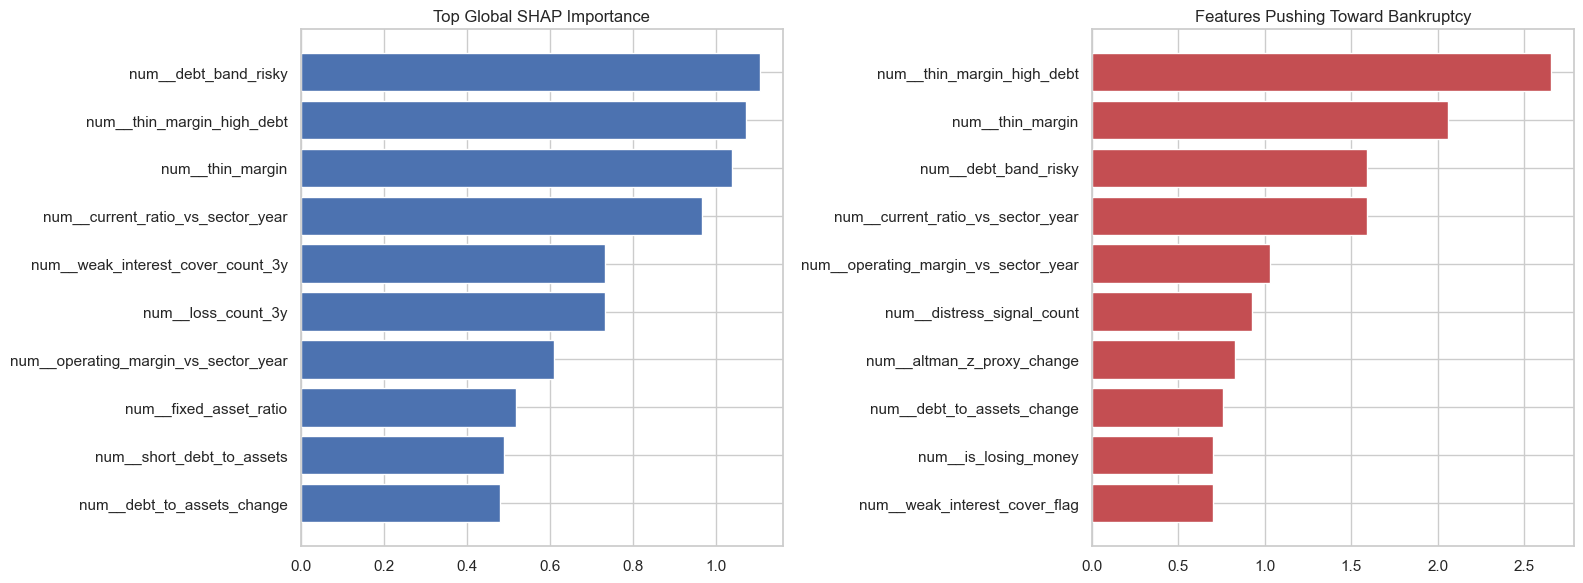

In [35]:
interpretation_artifacts = {}

fitted_preprocessor = best_pipeline.named_steps["preprocess"]
fitted_model = best_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

X_train_transformed = fitted_preprocessor.transform(X_train_holdout)
X_val_transformed = fitted_preprocessor.transform(X_val_holdout)

X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train_holdout.index)
X_val_transformed = pd.DataFrame(X_val_transformed, columns=feature_names, index=X_val_holdout.index)

explain_idx = sorted(set(
    y_val_holdout[y_val_holdout == 1].index.tolist() +
    y_val_holdout[y_val_holdout == 0].sample(min(250, int((y_val_holdout == 0).sum())), random_state=RANDOM_STATE).index.tolist()
))
X_explain = X_val_transformed.loc[explain_idx]

if best_model_name == "RegularizedLogistic":
    background = X_train_transformed.sample(min(400, len(X_train_transformed)), random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(fitted_model, background)
    shap_result = explainer(X_explain)
    shap_matrix = np.asarray(shap_result.values)
elif best_model_name == "XGBoost":

    xgb_explain_matrix = DMatrix(X_explain.to_numpy())
    shap_contribs = fitted_model.get_booster().predict(
        xgb_explain_matrix,
        pred_contribs=True,
    )
    shap_contribs = np.asarray(shap_contribs)
    if shap_contribs.ndim == 3:
        class_idx = 1 if shap_contribs.shape[1] > 1 else 0
        shap_contribs = shap_contribs[:, class_idx, :]
    shap_matrix = shap_contribs[:, :-1]
else:
    explainer = shap.TreeExplainer(fitted_model)
    shap_result = explainer.shap_values(X_explain)
    if isinstance(shap_result, list):
        shap_matrix = np.asarray(shap_result[1])
    else:
        shap_matrix = np.asarray(shap_result)
        if shap_matrix.ndim == 3:
            shap_matrix = shap_matrix[:, :, 1]

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

explain_prob = best_run["val_prob"][X_val_holdout.index.get_indexer(explain_idx)]
high_risk_mask = explain_prob >= best_f1_threshold
if high_risk_mask.sum() == 0:
    high_risk_mask = explain_prob >= np.quantile(explain_prob, 0.80)

risk_push_df = pd.DataFrame({
    "feature": feature_names,
    "mean_shap_on_high_risk_cases": shap_matrix[high_risk_mask].mean(axis=0),
}).sort_values("mean_shap_on_high_risk_cases", ascending=False)

interpretation_artifacts = {
    "mode": "shap",
    "shap_matrix": shap_matrix,
    "feature_frame": X_explain,
    "explain_index": explain_idx,
    "shap_importance_df": shap_importance_df,
    "risk_push_df": risk_push_df,
}

display(shap_importance_df.head(15))
display(risk_push_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_global = shap_importance_df.head(10).sort_values("mean_abs_shap", ascending=True)
axes[0].barh(top_global["feature"], top_global["mean_abs_shap"], color="#4c72b0")
axes[0].set_title("Top Global SHAP Importance")

top_positive = risk_push_df.head(10).sort_values("mean_shap_on_high_risk_cases", ascending=True)
axes[1].barh(top_positive["feature"], top_positive["mean_shap_on_high_risk_cases"], color="#c44e52")
axes[1].set_title("Features Pushing Toward Bankruptcy")

plt.tight_layout()
plt.savefig("../images/shap_importance.png", bbox_inches="tight", dpi=150)
plt.show()


### 9.1 Explaining an Individual Company

Global SHAP tells us which features matter overall. Here we zoom into a single actual bankrupt 
company (the one with the highest model-assigned probability), and decompose its score 
feature by feature. This gives a case-level explanation for review.

In [36]:
validation_explain_df = holdout_val_df[["company_id", "fiscal_year"]].copy()
validation_explain_df["actual"] = y_val_holdout.values
validation_explain_df["probability"] = best_run["val_prob"]

positive_cases = validation_explain_df[validation_explain_df["actual"] == 1].copy()
positive_cases = positive_cases[positive_cases.index.isin(interpretation_artifacts["explain_index"])]

if not positive_cases.empty:
    chosen_case = positive_cases.sort_values("probability", ascending=False).iloc[0]
    chosen_idx = chosen_case.name
    chosen_position = interpretation_artifacts["explain_index"].index(chosen_idx)

    local_explanation_df = pd.DataFrame({
        "feature": interpretation_artifacts["feature_frame"].columns,
        "feature_value": interpretation_artifacts["feature_frame"].iloc[chosen_position].values,
        "shap_value": interpretation_artifacts["shap_matrix"][chosen_position],
    }).sort_values("shap_value", ascending=False)

    display(chosen_case[["company_id", "fiscal_year", "probability"]])
    display(
        holdout_val_df.loc[[chosen_idx], [
            "current_ratio",
            "quick_ratio",
            "debt_to_assets",
            "profit_margin",
            "operating_margin",
            "equity_gap_pct_assets",
            "shareholders_equity",
            "net_profit_loss",
            "working_capital_to_assets",
            "interest_coverage_proxy",
            "distress_signal_count",
        ]]
    )
    display(local_explanation_df.head(15))


company_id     COMP_01585
fiscal_year          2021
probability      0.959391
Name: 9324, dtype: object

,current_ratio,quick_ratio,debt_to_assets,profit_margin,operating_margin,equity_gap_pct_assets,shareholders_equity,net_profit_loss,working_capital_to_assets,interest_coverage_proxy,distress_signal_count
9324,1.352,0.8112,0.8194,-0.0165,-0.000338,-0.533671,68241203.49,-7153267.21,0.176971,-0.020956,11


,feature,feature_value,shap_value
2,num__thin_margin_high_debt,1.000000,2.655715
26,num__thin_margin,1.000000,2.060947
21,num__debt_band_risky,1.000000,1.589621
34,num__distress_signal_count,2.750000,1.491902
14,num__operating_margin_vs_sector_year,-0.780637,1.250640
11,num__current_ratio_vs_sector_year,-0.378308,1.145009
33,num__weak_interest_cover_flag,1.000000,1.104049
32,num__is_losing_money,1.000000,1.104049
36,num__debt_to_assets_change,0.795206,1.047060
37,num__altman_z_proxy_change,-0.853311,0.887587


## 10. Interpreting the Risk Signals

Importance values are useful only if they match sensible financial logic. 
The drivers below are consistent with standard distress theory and with the EDA earlier in the notebook:

- **Negative profit and declining margins**: a company losing money is eroding its equity base and running out of runway
- **High debt-to-assets and leverage**: more of the balance sheet financed by creditors means less buffer when revenues dip
- **Weak interest coverage**: when EBIT no longer covers the interest bill, the company is paying creditors by selling assets or equity
- **Short-term debt pressure**: near-term refinancing requirements are especially dangerous when operating income is soft
- **Equity gap signals**: unexplained equity changes larger than net profit/loss sometimes indicate unusual capital movements, 
more common during economic shocks
- **Sector-relative deterioration**: a company can look mediocre in absolute terms but still be the weakest in its industry, 
and sector context matters for distress prediction

Taken together, these signals describe firms losing operating flexibility as earnings weaken.

## 11. Error Analysis

A strong ranking score does not mean every distressed firm is easy to separate at the chosen threshold.  
This section focuses on the validation-year mistakes, especially the **false negatives**: firms that did go bankrupt but were not flagged by the final classifier.

We check two questions:
- **How close were the missed bankruptcies to the decision threshold?**
- **Do the missed cases look systematically different from the bankruptcies the model did catch?**

This helps distinguish between two situations:
- firms that were genuinely hard to separate because their financial profile looked close to healthy companies
- firms that had recognizable distress signals, but not enough to cross the chosen operating threshold



,error_type,rows
0,True Negative,2894
1,False Positive,17
2,False Negative,16
3,True Positive,5


case_status,feature,Captured bankruptcies,Missed bankruptcies
0,probability,0.9465,0.7517
1,threshold_gap,0.0187,-0.1761
2,profit_margin,-0.0119,0.0005
3,operating_margin,-0.0003,0.0285
4,debt_to_assets,0.8083,0.7564
5,current_ratio,1.3520,1.5468
6,interest_coverage_proxy,-0.0210,1.1236
7,short_debt_pressure,-12.0448,6.2084
8,equity_gap_pct_assets,-0.0268,0.0495
9,distress_signal_count,8.0000,6.5000


,company_id,fiscal_year,ateco_sector,region,probability,threshold_gap,profit_margin,debt_to_assets,current_ratio,interest_coverage_proxy,short_debt_pressure,distress_signal_count
11973,COMP_02034,2021,25,Emilia-Romagna,0.8964,-0.0313,0.0162,0.8188,0.9456,1.5326,9.4342,8
11626,COMP_01976,2021,25,Lombardia,0.8820,-0.0458,-0.0013,0.8118,1.1677,0.9727,15.7234,11
17506,COMP_02977,2021,25,Lazio,0.8711,-0.0567,-0.0171,0.8505,1.0806,0.4101,50.4024,11
1583,COMP_00269,2021,47,Lombardia,0.8459,-0.0818,0.0120,0.8025,1.8836,1.5502,6.3504,4
17553,COMP_02985,2021,10,Sicilia,0.8105,-0.1173,-0.0048,0.7541,1.9889,0.8800,14.0981,8
26,COMP_00004,2021,46,Lombardia,0.7616,-0.1661,-0.0209,0.7168,1.9573,-4.0300,-5.4066,6
13260,COMP_02255,2021,46,Liguria,0.7582,-0.1696,-0.0202,0.7256,2.4254,-1.2456,-13.0602,7
14617,COMP_02487,2021,47,Emilia-Romagna,0.7566,-0.1712,0.0244,0.7243,1.6514,5.3560,5.8814,2
10474,COMP_01780,2021,10,Lazio,0.7468,-0.1809,-0.0199,0.8147,1.4017,-0.1805,-112.3968,11
14362,COMP_02443,2021,77,Veneto,0.7005,-0.2272,0.0121,0.7507,1.5547,1.8163,6.0664,4


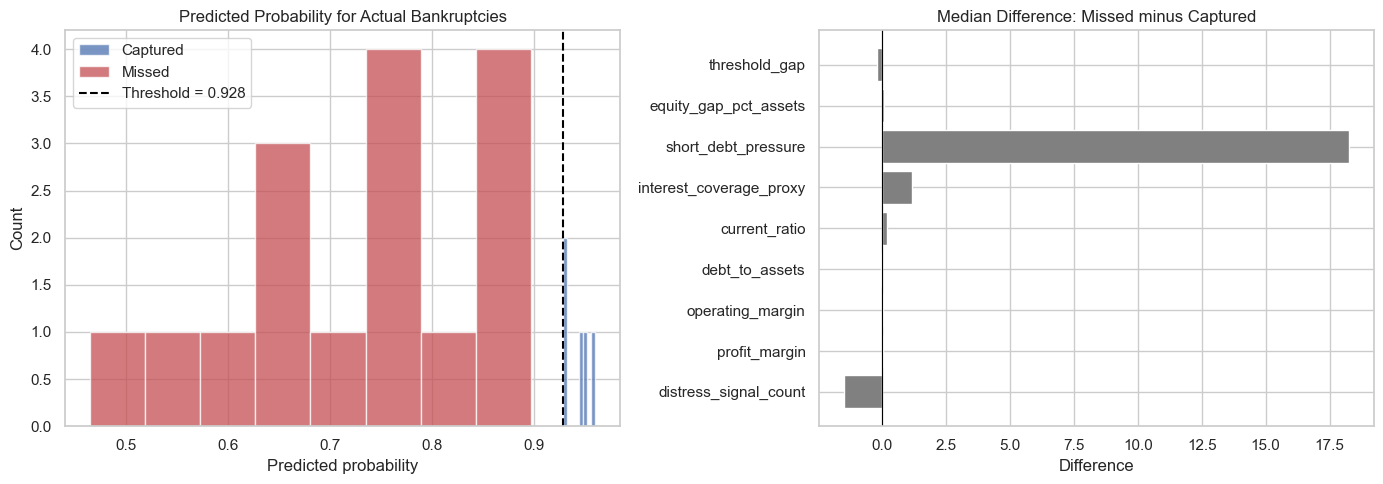

In [37]:
error_analysis_df = holdout_val_df[[
    "company_id",
    "fiscal_year",
    "ateco_sector",
    "region",
    "current_ratio",
    "debt_to_assets",
    "profit_margin",
    "operating_margin",
    "equity_gap_pct_assets",
    "short_debt_pressure",
    "interest_coverage_proxy",
    "distress_signal_count",
]].copy()
error_analysis_df["actual"] = y_val_holdout.values
error_analysis_df["probability"] = best_run["val_prob"]
error_analysis_df["predicted"] = (best_run["val_prob"] >= best_run["threshold"]).astype(int)
error_analysis_df["error_type"] = np.select(
    [
        (error_analysis_df["actual"] == 1) & (error_analysis_df["predicted"] == 1),
        (error_analysis_df["actual"] == 1) & (error_analysis_df["predicted"] == 0),
        (error_analysis_df["actual"] == 0) & (error_analysis_df["predicted"] == 1),
    ],
    ["True Positive", "False Negative", "False Positive"],
    default="True Negative",
)
error_analysis_df["threshold_gap"] = error_analysis_df["probability"] - best_run["threshold"]

error_count_df = (
    error_analysis_df["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="rows")
)
display(error_count_df)

captured_vs_missed_df = (
    error_analysis_df[error_analysis_df["actual"] == 1]
    .assign(case_status=lambda df: np.where(df["predicted"] == 1, "Captured bankruptcies", "Missed bankruptcies"))
)

comparison_features = [
    "probability",
    "threshold_gap",
    "profit_margin",
    "operating_margin",
    "debt_to_assets",
    "current_ratio",
    "interest_coverage_proxy",
    "short_debt_pressure",
    "equity_gap_pct_assets",
    "distress_signal_count",
]

missed_case_summary = (
    captured_vs_missed_df.groupby("case_status")[comparison_features]
    .median()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)
display(missed_case_summary.round(4))

display(
    error_analysis_df[error_analysis_df["error_type"] == "False Negative"]
    .sort_values(["probability", "distress_signal_count"], ascending=[False, False])
    [[
        "company_id",
        "fiscal_year",
        "ateco_sector",
        "region",
        "probability",
        "threshold_gap",
        "profit_margin",
        "debt_to_assets",
        "current_ratio",
        "interest_coverage_proxy",
        "short_debt_pressure",
        "distress_signal_count",
    ]]
    .head(10)
    .round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

captured_probs = captured_vs_missed_df.loc[
    captured_vs_missed_df["case_status"] == "Captured bankruptcies",
    "probability",
]
missed_probs = captured_vs_missed_df.loc[
    captured_vs_missed_df["case_status"] == "Missed bankruptcies",
    "probability",
]
axes[0].hist(captured_probs, bins=8, alpha=0.75, color="#4c72b0", label="Captured")
axes[0].hist(missed_probs, bins=8, alpha=0.75, color="#c44e52", label="Missed")
axes[0].axvline(best_run["threshold"], color="black", linestyle="--", label=f"Threshold = {best_run['threshold']:.3f}")
axes[0].set_title("Predicted Probability for Actual Bankruptcies")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Count")
axes[0].legend()

feature_gap_df = (
    missed_case_summary.set_index("feature")
    .assign(gap=lambda df: df["Missed bankruptcies"] - df["Captured bankruptcies"])
    .reindex([
        "distress_signal_count",
        "profit_margin",
        "operating_margin",
        "debt_to_assets",
        "current_ratio",
        "interest_coverage_proxy",
        "short_debt_pressure",
        "equity_gap_pct_assets",
        "threshold_gap",
    ])
)
axes[1].barh(feature_gap_df.index, feature_gap_df["gap"], color="#808080")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Median Difference: Missed minus Captured")
axes[1].set_xlabel("Difference")

plt.tight_layout()
plt.show()



## 12. Summary

This notebook builds a clean end-to-end bankruptcy prediction pipeline for Challenge 1:

- **EDA** showed that bankruptcy is rare and concentrated in firms with thin margins, high debt, weak coverage, and worsening year-over-year profiles
- **Feature engineering** translated those patterns into model-ready signals, including deterioration flags, distress counts, equity-gap variables, and sector-relative comparisons
- **Feature selection** was kept strictly time-valid on the 2020 validation year so that the 2021 model comparison stayed clean
- **Model comparison** on 2021 selected the final model by F1 while checking PR-AUC and ROC-AUC to confirm that the ranking quality was still strong under extreme class imbalance
- **Business threshold tuning** showed how the operating point changes once false negatives are treated as much more expensive than false positives
- **Final prediction export** refit the selected model on all labeled years and saved the 2022–2023 test predictions to CSV
- **Model interpretation** linked the final predictions back to sensible accounting and credit-risk mechanisms
- **Error analysis** showed that several missed bankruptcies sit close to the decision threshold or look financially less extreme than the captured bankruptcies, which helps explain why ranking remains stronger than thresholded F1

The main practical conclusion is simple: the highest-risk firms are usually not defined by one bad number alone. 
They tend to combine weak profitability, heavy debt pressure, and deterioration over time; no single ratio tells the full story.
